## Setup

In [1]:
# Packages not preinstalled on Colab (safe to re-run)
!pip install -q kagglehub --upgrade

In [2]:
import os, sys, re, time, json, random, hashlib, shutil, warnings
import xml.etree.ElementTree as ET
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

try:
    import cv2
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "opencv-python-headless"], check=True)
    import cv2

try:
    from skimage.feature import hog
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-image"], check=True)
    from skimage.feature import hog

import joblib
from joblib import Parallel, delayed
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

CONFIG = {
    "seed": SEED,
    # ---- data and preprocessing ----
    "classes": ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"],
    "img_size": 128,              # Track A: every image is resized to 128x128 grayscale
    "val_size": 0.15,
    "test_size": 0.15,
    # ---- HOG study (Task 11) ----
    "cell_sizes": [4, 8, 16],
    "orientations": [6, 9, 12],
    "hog_block": 2,               # 2x2 cells per block
    "hog_block_norm": "L2-Hys",
    "cv_folds": 5,
    "sweep_svm_C": 10,            # fixed SVM-RBF setting while the HOG settings are compared
    "parsimony_tol": 0.005,       # pick the smallest feature vector within 0.5 points of the best CV macro-F1
    # ---- Track B: Normal vs Defective windows ----
    "win_size": 64,
    "win_search_stride": 8,       # grid step used to look for box-free (Normal) windows
    "box_margin": 8,              # defect boxes are widened by this many pixels before the free-area check
    "max_def_windows_per_img": 2,
    "max_norm_windows_per_img": 3,
    "min_def_gap": 16,
    "min_norm_gap": 48,
    "scan_stride": 34,            # decision module: 5x5 windows over a 200x200 image
    "reject_threshold": 0.5,      # decision module: REJECT if the most suspicious window has P(defect) >= this
    # ---- classifier settings ----
    "svm_C_grid": [1, 10, 100, 1000],
    "svm_gamma_mult_grid": [0.25, 0.5, 1.0, 2.0, 4.0],      # multiples of sklearn's gamma="scale"
    "svm_C_grid_bin": [1, 10, 100],
    "svm_gamma_mult_grid_bin": [0.5, 1.0, 2.0],
    "linsvm_C_grid": [0.1, 1, 10],
    "knn_k_grid": [1, 3, 5, 7, 9],
    "lr_C_grid": [1, 10, 100],
    "rf_trees": 300,
    # ---- Task 12: robustness levels ----
    "robust_levels": {
        "brightness": [0.5, 0.75, 1.25, 1.5],     # gain applied to the grayscale image
        "noise": [5, 10, 20, 40],                 # Gaussian noise sigma (0-255 scale)
        "rotation": [5, 15, 45, 90],              # degrees
        "blur": [1, 2, 3, 5],                     # Gaussian blur sigma in pixels
    },
    # ---- compute and persistence (these keys are NOT part of the run id) ----
    "n_jobs": -1,
    "save_to_drive": True,
    "drive_folder": "Lab05_NEU_HOG",
}
CONFIG

{'seed': 42,
 'classes': ['crazing',
  'inclusion',
  'patches',
  'pitted_surface',
  'rolled-in_scale',
  'scratches'],
 'img_size': 128,
 'val_size': 0.15,
 'test_size': 0.15,
 'cell_sizes': [4, 8, 16],
 'orientations': [6, 9, 12],
 'hog_block': 2,
 'hog_block_norm': 'L2-Hys',
 'cv_folds': 5,
 'sweep_svm_C': 10,
 'parsimony_tol': 0.005,
 'win_size': 64,
 'win_search_stride': 8,
 'box_margin': 8,
 'max_def_windows_per_img': 2,
 'max_norm_windows_per_img': 3,
 'min_def_gap': 16,
 'min_norm_gap': 48,
 'scan_stride': 34,
 'reject_threshold': 0.5,
 'svm_C_grid': [1, 10, 100, 1000],
 'svm_gamma_mult_grid': [0.25, 0.5, 1.0, 2.0, 4.0],
 'svm_C_grid_bin': [1, 10, 100],
 'svm_gamma_mult_grid_bin': [0.5, 1.0, 2.0],
 'linsvm_C_grid': [0.1, 1, 10],
 'knn_k_grid': [1, 3, 5, 7, 9],
 'lr_C_grid': [1, 10, 100],
 'rf_trees': 300,
 'robust_levels': {'brightness': [0.5, 0.75, 1.25, 1.5],
  'noise': [5, 10, 20, 40],
  'rotation': [5, 15, 45, 90],
  'blur': [1, 2, 3, 5]},
 'n_jobs': -1,
 'save_to_drive':

In [3]:
# ---- run id, Google Drive, and checkpoint folders ----
SIG_EXCLUDE = {"n_jobs", "save_to_drive", "drive_folder"}
RUN_SIG = hashlib.md5(
    json.dumps({k: v for k, v in CONFIG.items() if k not in SIG_EXCLUDE}, sort_keys=True).encode()
).hexdigest()[:8]

BASE_DIR = "/content/lab05_local_ckpt"        # used only if Drive cannot be mounted
DRIVE_OK = False
if CONFIG["save_to_drive"]:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        BASE_DIR = os.path.join("/content/drive/MyDrive", CONFIG["drive_folder"])
        DRIVE_OK = True
    except Exception as e:
        print("Google Drive is not available here:", repr(e))
        print("Checkpoints go to", BASE_DIR, "(LOCAL ONLY: they are lost if the runtime resets)")

CKPT_DIR = os.path.join(BASE_DIR, f"run_{RUN_SIG}")
MODEL_DIR = os.path.join(CKPT_DIR, "models")
FIG_DIR = os.path.join(CKPT_DIR, "figures")
RESULTS_DIR = "/content/lab05_results"        # figures are written here first, then copied to Drive
for d in (CKPT_DIR, MODEL_DIR, FIG_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)
print("Run id:", RUN_SIG)
print("Checkpoint folder:", CKPT_DIR, "(Google Drive)" if DRIVE_OK else "(local)")


def _json_default(o):
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)


def _atomic_write(path, text):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        f.write(text)
    os.replace(tmp, path)          # a disconnect can never leave a half-written file behind


class JsonStore:
    """extras.json style checkpoint for small results (best settings, predictions, thresholds)."""
    def __init__(self, filename):
        self.path = os.path.join(CKPT_DIR, filename)
        self.data = {}
        if os.path.exists(self.path):
            try:
                self.data = json.load(open(self.path))
                print(f"  [{filename}] loaded {len(self.data)} saved entries")
            except Exception:
                self.data = {}
    def has(self, key): return key in self.data
    def get(self, key, default=None): return self.data.get(key, default)
    def set(self, key, value):
        self.data[key] = value
        _atomic_write(self.path, json.dumps(self.data, default=_json_default))


class RowStore:
    """results.csv style checkpoint: one row per finished unit of work, saved after every unit."""
    def __init__(self, filename, key_cols, str_cols=()):
        self.path = os.path.join(CKPT_DIR, filename)
        self.key_cols = list(key_cols)
        self.df = pd.DataFrame()
        if os.path.exists(self.path):
            self.df = pd.read_csv(self.path, dtype={c: str for c in str_cols}, float_precision="round_trip")
            print(f"  [{filename}] loaded {len(self.df)} finished rows")
    def _mask(self, key):
        m = np.ones(len(self.df), dtype=bool)
        for k, v in key.items():
            m &= (self.df[k].astype(str) == str(v)).to_numpy()
        return m
    def done(self, **key):
        return (not self.df.empty) and bool(self._mask(key).any())
    def where(self, **key):
        return self.df if self.df.empty else self.df[self._mask(key)]
    def add(self, row):
        new = pd.DataFrame([row])
        self.df = new if self.df.empty else pd.concat([self.df, new], ignore_index=True)
        tmp = self.path + ".tmp"
        self.df.to_csv(tmp, index=False, float_format="%.17g")      # exact round trip: a resumed run reproduces every number
        os.replace(tmp, self.path)


class Lazy:
    """Compute something only when it is first needed (so a resumed run can skip expensive steps)."""
    def __init__(self, fn): self.fn, self.v = fn, None
    def get(self):
        if self.v is None: self.v = self.fn()
        return self.v


EXTRAS = JsonStore("extras.json")


def _clean_axis(ax):
    '''Hide ticks/spines but keep title/xlabel/ylabel visible (unlike ax.axis("off"),
    which hides the labels too).'''
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def save_fig(name, fig=None):
    fig = fig or plt.gcf()
    path = os.path.join(RESULTS_DIR, name + ".png")
    fig.savefig(path, dpi=130, bbox_inches="tight")
    try:
        shutil.copy(path, os.path.join(FIG_DIR, name + ".png"))
    except Exception as e:
        print("(figure could not be copied to the checkpoint folder)", e)

Mounted at /content/drive
Run id: 37c9b548
Checkpoint folder: /content/drive/MyDrive/Lab05_NEU_HOG/run_37c9b548 (Google Drive)


## Task 1: Load and inspect dataset

In [4]:
import kagglehub

DATA_DIR = kagglehub.dataset_download("sovitrath/neu-steel-surface-defect-detect-trainvalid-split")
print("Path to dataset files:", DATA_DIR)

print("\nTop-level contents of", DATA_DIR)
for root, dirs, fnames in os.walk(DATA_DIR):
    depth = root[len(DATA_DIR):].count(os.sep)
    if depth <= 1:
        print(root, "->", dirs[:10], f"(+{len(fnames)} files)" if fnames else "")

100%|██████████| 26.3M/26.3M [00:02<00:00, 10.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1

Top-level contents of /root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1 -> ['valid_images', 'valid_annotations', 'train_annotations', 'train_images'] 
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1/valid_images -> [] (+100 files)
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1/valid_annotations -> [] (+100 files)
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1/train_annotations -> [] (+1700 files)
/root/.cache/kagglehub/datasets/sovitrath/neu-steel-surface-defect-detect-trainvalid-split/versions/1/train_images -> [] (+1700 files)


In [5]:
# ---- index every image and its XML boxes ----
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
all_files = [os.path.join(r, f) for r, _, fs in os.walk(DATA_DIR) for f in fs]
img_files = sorted(p for p in all_files if p.lower().endswith(IMG_EXT))
xml_files = sorted(p for p in all_files if p.lower().endswith(".xml"))
print(f"Found {len(img_files)} images and {len(xml_files)} XML annotation files")
assert img_files, "No images found under DATA_DIR (check the download)."


def _norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

CLASS_BY_NORM = {_norm(c): c for c in CONFIG["classes"]}

def canon_class(name):
    return CLASS_BY_NORM.get(_norm(name))

def label_from_stem(stem):
    m = re.match(r"^(.*?)[_\-]?(\d+)$", stem)
    return canon_class(m.group(1)) if m else canon_class(stem)

def parse_voc(xml_path):
    try:
        root = ET.parse(xml_path).getroot()
    except Exception:
        return None
    objs = []
    for o in root.findall("object"):
        bb = o.find("bndbox")
        if bb is None:
            continue
        try:
            x1, y1, x2, y2 = [float(bb.findtext(k)) for k in ("xmin", "ymin", "xmax", "ymax")]
        except (TypeError, ValueError):
            continue
        objs.append(((o.findtext("name") or "").strip(), x1, y1, x2, y2))
    return {"filename": root.findtext("filename"), "objects": objs}

xml_info, xml_by_stem = {}, {}
for p in xml_files:
    info = parse_voc(p)
    if info is None:
        continue
    xml_info[p] = info
    xml_by_stem.setdefault(os.path.splitext(os.path.basename(p))[0], p)
    if info["filename"]:
        xml_by_stem.setdefault(os.path.splitext(os.path.basename(info["filename"]))[0], p)

rows = []
for p in img_files:
    rel = os.path.relpath(p, DATA_DIR).replace("\\", "/")
    stem = os.path.splitext(os.path.basename(p))[0]
    parts = rel.lower().split("/")[:-1]
    src = "valid" if any(x.startswith("val") for x in parts) else ("train" if any(x.startswith("train") for x in parts) else "other")
    xp = xml_by_stem.get(stem)
    info = xml_info.get(xp) if xp else None
    boxes, xml_names = [], []
    if info:
        for (nm, x1, y1, x2, y2) in info["objects"]:
            boxes.append([min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)])
            xml_names.append(canon_class(nm) or str(nm))
    lab_file = label_from_stem(stem)
    lab_xml = Counter(xml_names).most_common(1)[0][0] if xml_names else None
    lab_dir = canon_class(os.path.basename(os.path.dirname(p)))
    rows.append(dict(uid=os.path.splitext(rel)[0], stem=stem, path=p, xml_path=xp, src=src,
                     label=lab_file or lab_xml or lab_dir, label_file=lab_file, label_xml=lab_xml,
                     n_boxes=len(boxes), boxes=boxes, xml_classes=",".join(sorted(set(xml_names)))))
meta = pd.DataFrame(rows)

bad = meta[meta["label"].isna()]
assert len(bad) == 0, f"Could not work out the class for {len(bad)} images, for example: {bad['stem'].head().tolist()}"
both = meta[meta["label_file"].notna() & meta["label_xml"].notna()]
print(f"\nClass taken from the file name for {meta['label_file'].notna().sum()} images; "
      f"{meta['n_boxes'].gt(0).sum()} images have at least one XML box")
print(f"File-name class and XML class disagree for {(both['label_file'] != both['label_xml']).sum()} of {len(both)} images")
print(f"Images whose XML lists more than one defect type: {meta['xml_classes'].str.contains(',').sum()}")

CLASSES = [c for c in CONFIG["classes"] if c in set(meta["label"])]
label2idx = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
print("\nClasses:", CLASSES, "| NUM_CLASSES =", NUM_CLASSES)
print(pd.crosstab(meta["label"], meta["src"]).reindex(CLASSES))

Found 1800 images and 1800 XML annotation files

Class taken from the file name for 1800 images; 1800 images have at least one XML box
File-name class and XML class disagree for 22 of 1800 images
Images whose XML lists more than one defect type: 123

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches'] | NUM_CLASSES = 6
src              train  valid
label                        
crazing            283     17
inclusion          283     17
patches            284     16
pitted_surface     283     17
rolled-in_scale    283     17
scratches          284     16


In [6]:
# ---- load every image once (native resolution, grayscale) and look at what is really stored ----
t0 = time.time()
GRAY_NATIVE, modes, sizes = [], [], []
for p in meta["path"]:
    im = Image.open(p)
    modes.append(im.mode); sizes.append(im.size)
    GRAY_NATIVE.append(np.array(im.convert("L")))
meta["W"] = [s[0] for s in sizes]; meta["H"] = [s[1] for s in sizes]
print(f"Loaded {len(GRAY_NATIVE)} images in {time.time() - t0:.1f}s")
print("Stored colour modes:", dict(Counter(modes)))
print("Image sizes (W, H):", dict(Counter(sizes)))

rng_chk = np.random.RandomState(SEED)
diffs = []
for i in rng_chk.choice(len(meta), size=min(40, len(meta)), replace=False):
    a = np.array(Image.open(meta.at[i, "path"]).convert("RGB")).astype(int)
    diffs.append(int(np.abs(a[..., 0] - a[..., 1]).max() + np.abs(a[..., 1] - a[..., 2]).max()))
print("Largest difference between colour channels over 40 random images:", max(diffs),
      "(0 means the 3 channels are identical, i.e. the images are really grayscale)")

def clip_boxes(boxes, W, H):
    out = []
    for x1, y1, x2, y2 in boxes:
        x1, x2 = float(np.clip(x1, 0, W)), float(np.clip(x2, 0, W))
        y1, y2 = float(np.clip(y1, 0, H)), float(np.clip(y2, 0, H))
        if x2 - x1 >= 2 and y2 - y1 >= 2:
            out.append([x1, y1, x2, y2])
    return out

meta["boxes"] = [clip_boxes(b, w, h) for b, w, h in zip(meta["boxes"], meta["W"], meta["H"])]
meta["n_boxes"] = meta["boxes"].map(len)

def box_cover(boxes, W, H):
    m = np.zeros((H, W), dtype=bool)
    for x1, y1, x2, y2 in boxes:
        m[int(y1):int(np.ceil(y2)), int(x1):int(np.ceil(x2))] = True
    return float(m.mean())

meta["box_cover"] = [box_cover(b, w, h) for b, w, h in zip(meta["boxes"], meta["W"], meta["H"])]

summary = meta.groupby("label").agg(images=("uid", "size"), boxes_per_img=("n_boxes", "mean"),
                                    mean_box_cover=("box_cover", "mean")).reindex(CLASSES)
summary["mean_box_cover"] = (100 * summary["mean_box_cover"]).round(1)
summary["boxes_per_img"] = summary["boxes_per_img"].round(2)
print("\nPer-class summary (mean_box_cover = % of the image area covered by defect boxes):")
print(summary.to_string())

Loaded 1800 images in 1.0s
Stored colour modes: {'RGB': 1800}
Image sizes (W, H): {(200, 200): 1800}
Largest difference between colour channels over 40 random images: 0 (0 means the 3 channels are identical, i.e. the images are really grayscale)

Per-class summary (mean_box_cover = % of the image area covered by defect boxes):
                 images  boxes_per_img  mean_box_cover
label                                                 
crazing             300           2.31            50.0
inclusion           300           2.95            21.3
patches             300           2.91            36.0
pitted_surface      300           1.63            80.8
rolled-in_scale     300           2.09            29.9
scratches           300           2.07            17.9


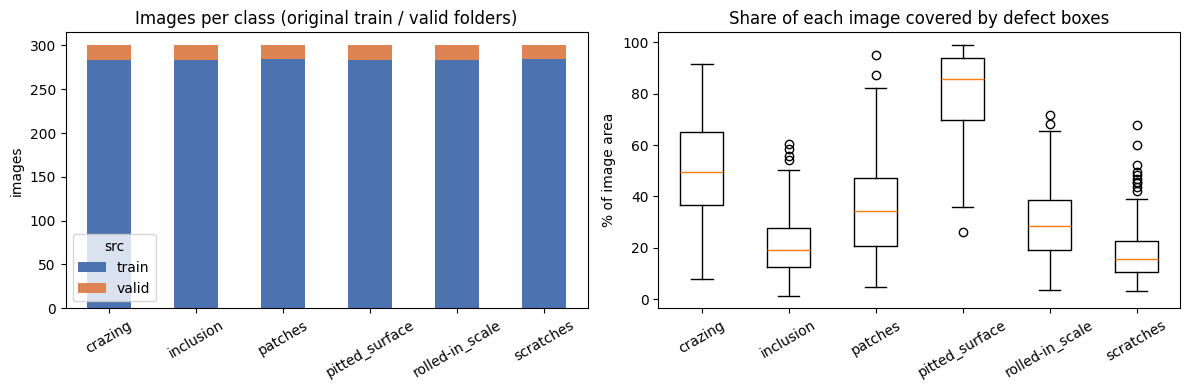

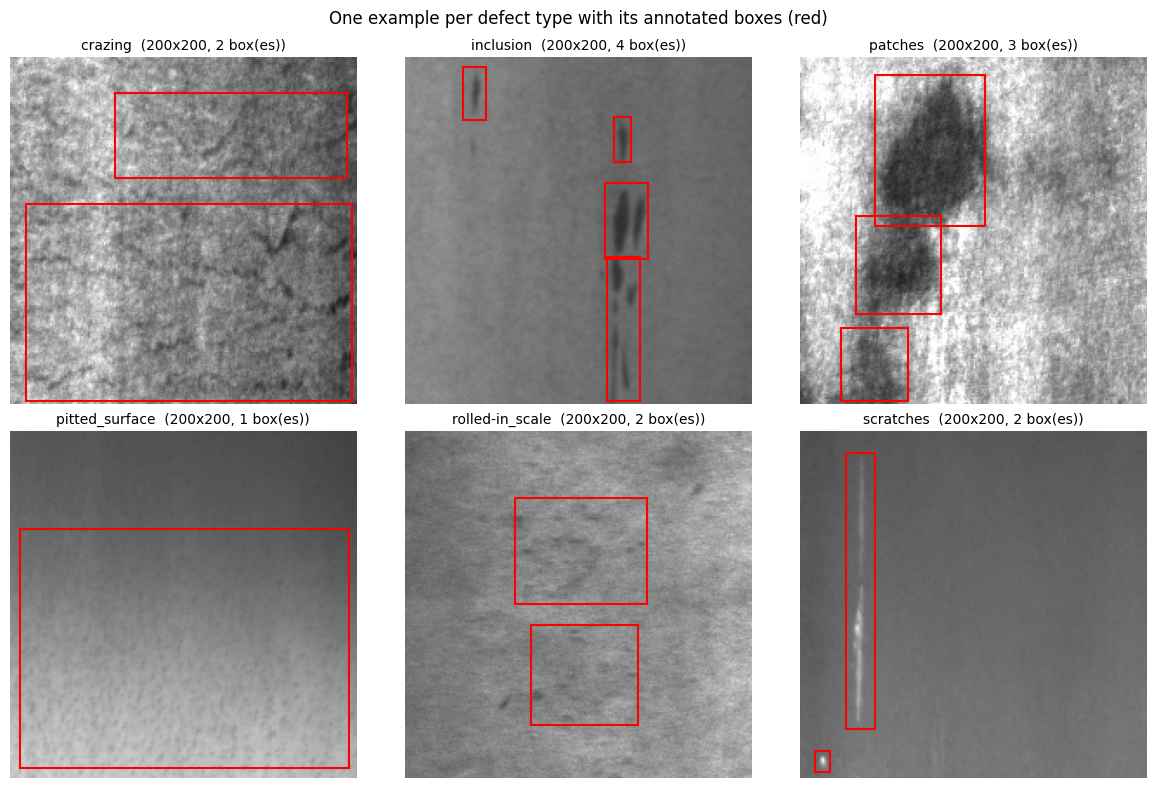

In [7]:
# ---- figures: class balance, box coverage, and one annotated example per class ----
REP_IDX = {}
for c in CLASSES:
    cand = meta[(meta["label"] == c) & (meta["n_boxes"] > 0)]
    REP_IDX[c] = int((cand if len(cand) else meta[meta["label"] == c]).index[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cnt = pd.crosstab(meta["label"], meta["src"]).reindex(CLASSES)
cnt.plot(kind="bar", stacked=True, ax=axes[0], color=["#4c72b0", "#dd8452", "#999999"][:cnt.shape[1]])
axes[0].set_title("Images per class (original train / valid folders)"); axes[0].set_xlabel(""); axes[0].set_ylabel("images")
axes[0].tick_params(axis="x", rotation=30)
axes[1].boxplot([100 * meta.loc[meta["label"] == c, "box_cover"].to_numpy() for c in CLASSES])
axes[1].set_xticks(range(1, len(CLASSES) + 1)); axes[1].set_xticklabels(CLASSES, rotation=30)
axes[1].set_title("Share of each image covered by defect boxes"); axes[1].set_ylabel("% of image area")
plt.tight_layout(); save_fig("task1_class_distribution_and_box_cover"); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, c in zip(axes.ravel(), CLASSES):
    i = REP_IDX[c]
    ax.imshow(GRAY_NATIVE[i], cmap="gray", vmin=0, vmax=255)
    for x1, y1, x2, y2 in meta.at[i, "boxes"]:
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1.5))
    ax.set_title(f"{c}  ({meta.at[i, 'W']}x{meta.at[i, 'H']}, {meta.at[i, 'n_boxes']} box(es))", fontsize=10)
    _clean_axis(ax)
plt.suptitle("One example per defect type with its annotated boxes (red)")
plt.tight_layout(); save_fig("task1_sample_images_with_boxes"); plt.show()

In [8]:
# ---- stratified 70/15/15 split (seed 42), saved so a resumed run uses the identical split ----
dev_frac = CONFIG["val_size"] + CONFIG["test_size"]
all_idx = np.arange(len(meta))
tr_idx, tmp_idx = train_test_split(all_idx, test_size=dev_frac, stratify=meta["label"], random_state=SEED)
va_idx, te_idx = train_test_split(tmp_idx, test_size=CONFIG["test_size"] / dev_frac,
                                  stratify=meta["label"].to_numpy()[tmp_idx], random_state=SEED)
meta["split"] = "train"
meta.loc[va_idx, "split"] = "val"
meta.loc[te_idx, "split"] = "test"

split_now = {s: sorted(meta.loc[meta["split"] == s, "uid"].tolist()) for s in ("train", "val", "test")}
saved = EXTRAS.get("split")
if saved is None:
    EXTRAS.set("split", split_now)
elif saved != split_now:
    print("WARNING: the split differs from the one saved in the checkpoint folder; using the saved one so earlier results stay valid.")
    uid2split = {u: s for s, us in saved.items() for u in us}
    meta["split"] = meta["uid"].map(uid2split)
    assert meta["split"].notna().all(), "Saved split does not match the dataset files."

dev_idx = np.where(meta["split"].isin(["train", "val"]))[0]
test_idx = np.where(meta["split"] == "test")[0]
y_all = meta["label"].map(label2idx).to_numpy()
y_dev, y_test = y_all[dev_idx], y_all[test_idx]
print(f"Split: train {int((meta['split'] == 'train').sum())} / val {int((meta['split'] == 'val').sum())} / test {len(test_idx)}"
      f"   (development set = train + val = {len(dev_idx)})")
print(pd.crosstab(meta["label"], meta["split"]).reindex(CLASSES)[["train", "val", "test"]])

Split: train 1260 / val 270 / test 270   (development set = train + val = 1530)
split            train  val  test
label                            
crazing            210   45    45
inclusion          210   45    45
patches            210   45    45
pitted_surface     210   45    45
rolled-in_scale    210   45    45
scratches          210   45    45


## 3. Tasks 2 and 3: Resize to a common resolution and convert to grayscale

Track A input array: (1800, 128, 128) uint8 | pixel range 0 to 255


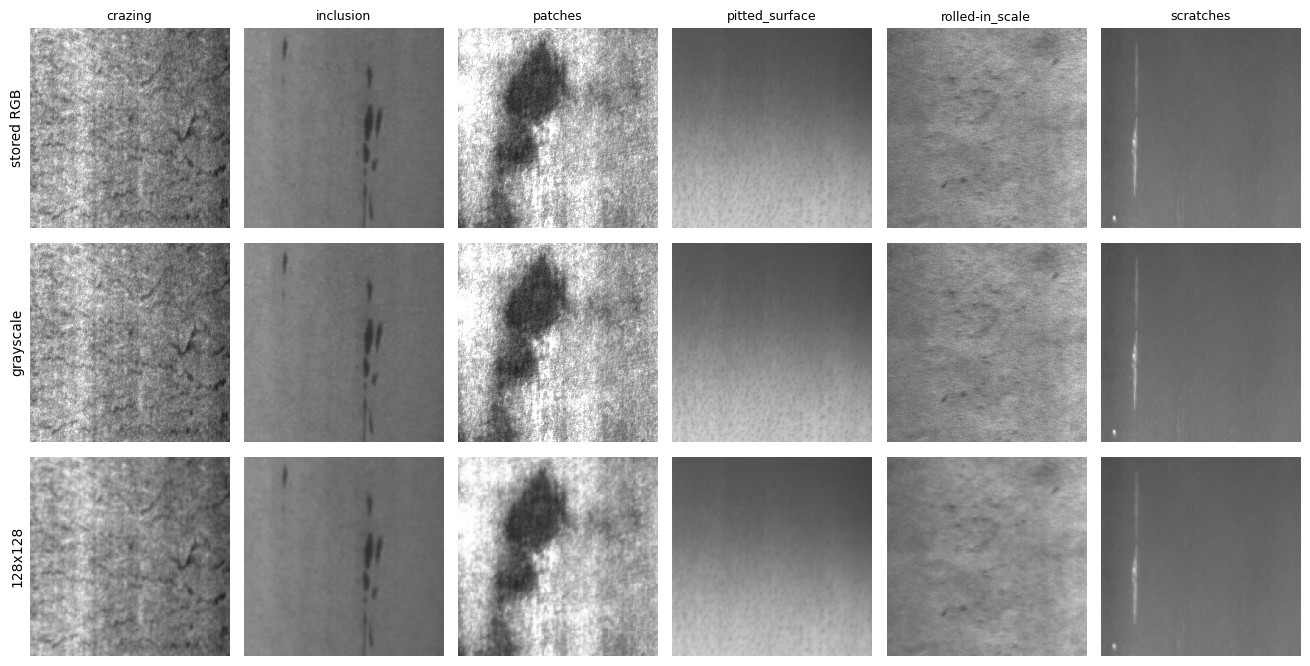

In [9]:
S = CONFIG["img_size"]

def preprocess_full(g):
    '''native grayscale image -> S x S grayscale (area interpolation)'''
    return cv2.resize(g, (S, S), interpolation=cv2.INTER_AREA)

IMG128 = np.stack([preprocess_full(g) for g in GRAY_NATIVE])
print("Track A input array:", IMG128.shape, IMG128.dtype, "| pixel range", int(IMG128.min()), "to", int(IMG128.max()))

fig, axes = plt.subplots(3, len(CLASSES), figsize=(2.2 * len(CLASSES), 6.8))
for j, c in enumerate(CLASSES):
    i = REP_IDX[c]
    axes[0, j].imshow(np.array(Image.open(meta.at[i, "path"]).convert("RGB"))); axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(GRAY_NATIVE[i], cmap="gray", vmin=0, vmax=255)
    axes[2, j].imshow(IMG128[i], cmap="gray", vmin=0, vmax=255)
    for r in range(3):
        _clean_axis(axes[r, j])
axes[0, 0].set_ylabel("stored RGB"); axes[1, 0].set_ylabel("grayscale"); axes[2, 0].set_ylabel(f"{S}x{S}")
plt.tight_layout(); save_fig("task2_3_resize_grayscale"); plt.show()

## Tasks 4 and 5: HOG feature extraction and visualisation

In [10]:
HB, HNORM = CONFIG["hog_block"], CONFIG["hog_block_norm"]
WIN = CONFIG["win_size"]

def hog_vec(img, cell, orient):
    return hog(img, orientations=orient, pixels_per_cell=(cell, cell), cells_per_block=(HB, HB),
               block_norm=HNORM, feature_vector=True).astype(np.float32)

def hog_dim(size, cell, orient):
    n_blocks = max(size // cell - HB + 1, 0)
    return n_blocks * n_blocks * HB * HB * orient

def hog_batch(imgs, cell, orient):
    out = Parallel(n_jobs=CONFIG["n_jobs"])(delayed(hog_vec)(im, cell, orient) for im in imgs)
    return np.stack(out)

def hog_picture(img, cell, orient):
    _, h = hog(img, orientations=orient, pixels_per_cell=(cell, cell), cells_per_block=(HB, HB),
               block_norm=HNORM, visualize=True, feature_vector=True)
    return h / (h.max() + 1e-9)

# sanity check: the feature-length formula matches what skimage really returns
for sz in (S, WIN):
    for cell in CONFIG["cell_sizes"]:
        for o in CONFIG["orientations"]:
            assert hog_vec(np.zeros((sz, sz), np.uint8), cell, o).shape[0] == hog_dim(sz, cell, o)

def time_hog(imgs, cell, orient, n=30):
    t0 = time.perf_counter()
    for im in imgs[:n]:
        hog_vec(im, cell, orient)
    return 1000 * (time.perf_counter() - t0) / n

crops_for_timing = [g[:WIN, :WIN] for g in GRAY_NATIVE[:30]]
rows = []
for cell in CONFIG["cell_sizes"]:
    for o in CONFIG["orientations"]:
        rows.append(dict(cell=cell, orient=o, dim_128=hog_dim(S, cell, o), ms_128=time_hog(IMG128, cell, o),
                         dim_64=hog_dim(WIN, cell, o), ms_64=time_hog(crops_for_timing, cell, o)))
HOG_COST = pd.DataFrame(rows)
EXTRAS.set("hog_cost", HOG_COST.round(3).to_dict("records"))
print("HOG feature length and single-thread extraction time per image (dim_128 / ms_128: whole image, Track A;")
print("dim_64 / ms_64: window, Track B):")
print(HOG_COST.round(2).to_string(index=False))

HOG feature length and single-thread extraction time per image (dim_128 / ms_128: whole image, Track A;
dim_64 / ms_64: window, Track B):
 cell  orient  dim_128  ms_128  dim_64  ms_64
    4       6    23064   34.52    5400   8.08
    4       9    34596   38.23    8100   9.10
    4      12    46128   35.68   10800   5.66
    8       6     5400    6.08    1176   1.43
    8       9     8100    6.20    1764   1.54
    8      12    10800    6.57    2352   1.55
   16       6     1176    2.61     216   0.64
   16       9     1764    3.17     324   1.00
   16      12     2352    3.23     432   0.74


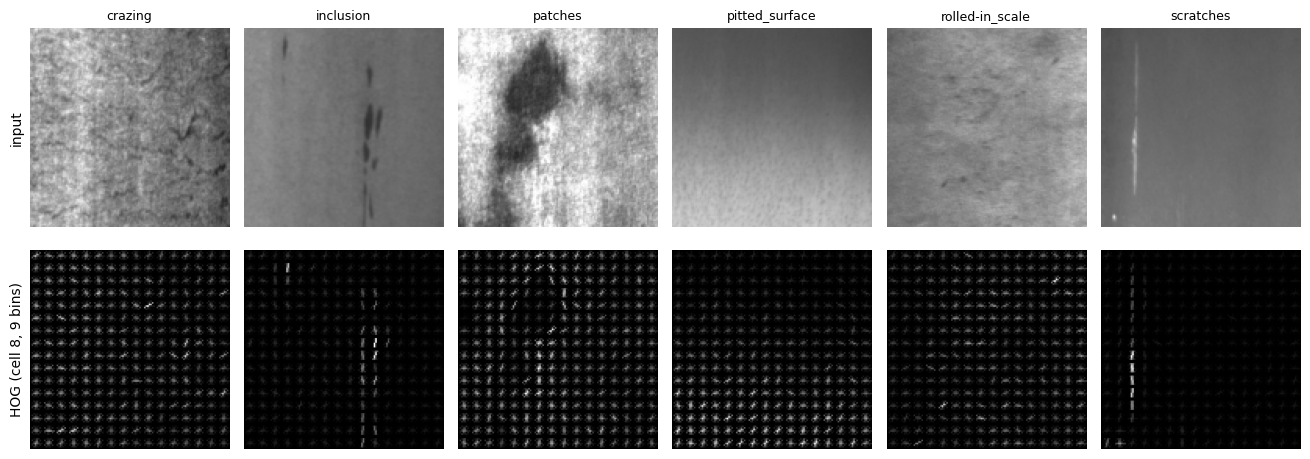

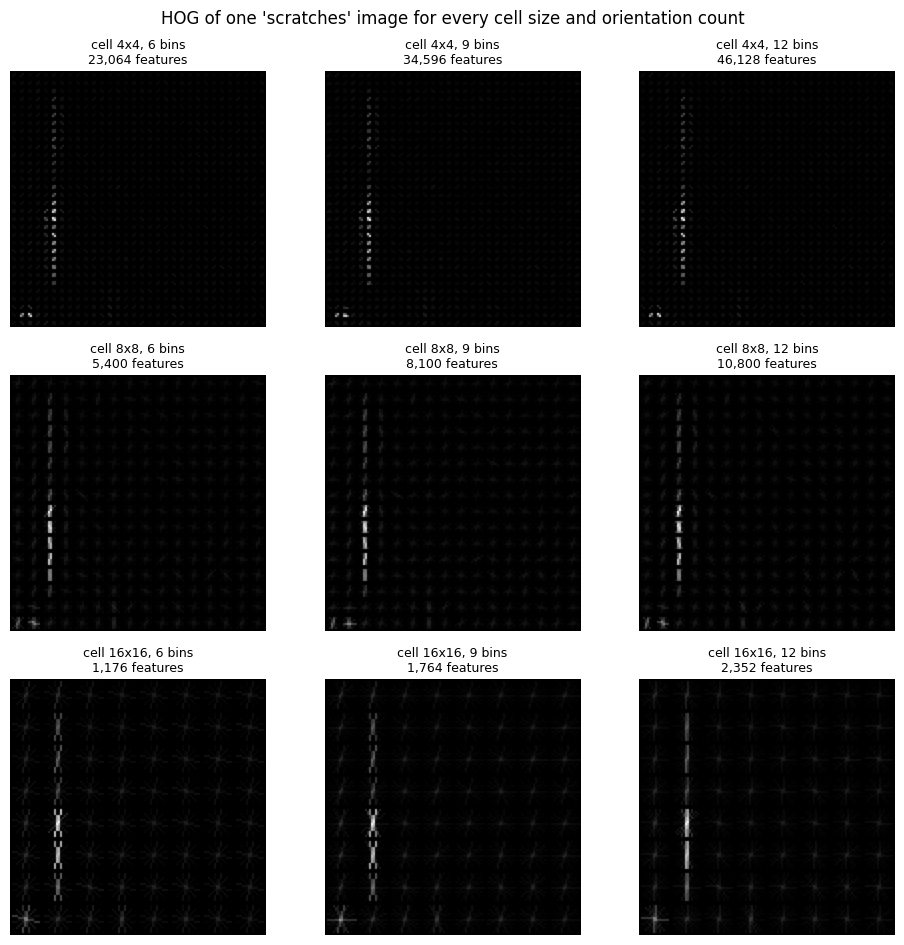

In [11]:
# Task 5: HOG pictures. Left to right: the 6 defect types. Bright strokes show the dominant gradient directions.
fig, axes = plt.subplots(2, len(CLASSES), figsize=(2.2 * len(CLASSES), 4.9))
for j, c in enumerate(CLASSES):
    img = IMG128[REP_IDX[c]]
    axes[0, j].imshow(img, cmap="gray", vmin=0, vmax=255); axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(hog_picture(img, 8, 9), cmap="gray")
    for r in range(2):
        _clean_axis(axes[r, j])
axes[0, 0].set_ylabel("input"); axes[1, 0].set_ylabel("HOG (cell 8, 9 bins)")
plt.tight_layout(); save_fig("task5_hog_per_class"); plt.show()

# How the two HOG settings change the picture of ONE image (rows: cell size, columns: orientations)
demo_c = "scratches" if "scratches" in CLASSES else CLASSES[-1]
demo_img = IMG128[REP_IDX[demo_c]]
fig, axes = plt.subplots(len(CONFIG["cell_sizes"]), len(CONFIG["orientations"]), figsize=(3.2 * len(CONFIG["orientations"]), 3.2 * len(CONFIG["cell_sizes"])))
for r, cell in enumerate(CONFIG["cell_sizes"]):
    for c_, o in enumerate(CONFIG["orientations"]):
        axes[r, c_].imshow(hog_picture(demo_img, cell, o), cmap="gray")
        axes[r, c_].set_title(f"cell {cell}x{cell}, {o} bins\n{hog_dim(S, cell, o):,} features", fontsize=9)
        _clean_axis(axes[r, c_])
plt.suptitle(f"HOG of one '{demo_c}' image for every cell size and orientation count")
plt.tight_layout(); save_fig("task5_hog_cell_orientation_grid"); plt.show()

## Track B data: Normal vs Defective windows

In [12]:
assert (meta["n_boxes"] > 0).any(), (
    "No XML boxes were found, so Normal windows cannot be built. Tell Claude what the dataset folders look like and Track B will be adapted.")

def free_window_positions(H, W, boxes, win, stride, margin):
    '''top-left corners of win x win windows that touch no box (boxes widened by margin)'''
    if H < win or W < win:
        return np.zeros((0, 2), dtype=int)
    xs, ys = list(range(0, W - win + 1, stride)), list(range(0, H - win + 1, stride))
    if xs[-1] != W - win: xs.append(W - win)
    if ys[-1] != H - win: ys.append(H - win)
    cand = np.array([(x, y) for y in ys for x in xs])
    if len(boxes) == 0:
        return cand
    b = np.asarray(boxes, dtype=float)
    hit = ((cand[:, 0:1] < b[None, :, 2] + margin) & (cand[:, 0:1] + win > b[None, :, 0] - margin) &
           (cand[:, 1:2] < b[None, :, 3] + margin) & (cand[:, 1:2] + win > b[None, :, 1] - margin)).any(axis=1)
    return cand[~hit]

def pick_spread(cands, k, gap, rng):
    chosen = []
    for i in rng.permutation(len(cands)):
        x, y = cands[i]
        if all(max(abs(x - cx), abs(y - cy)) >= gap for cx, cy in chosen):
            chosen.append((int(x), int(y)))
            if len(chosen) == k:
                break
    return chosen

def defect_window_positions(H, W, boxes, win, k, gap, rng):
    chosen = []
    for i in rng.permutation(len(boxes)):
        x1, y1, x2, y2 = boxes[i]
        x0 = int(np.clip(round((x1 + x2) / 2 - win / 2), 0, W - win))
        y0 = int(np.clip(round((y1 + y2) / 2 - win / 2), 0, H - win))
        if all(max(abs(x0 - cx), abs(y0 - cy)) >= gap for cx, cy in chosen):
            chosen.append((x0, y0))
            if len(chosen) == k:
                break
    return chosen

def build_windows():
    rows, crops = [], []
    for i in range(len(meta)):
        g = GRAY_NATIVE[i]
        H, W = g.shape
        boxes = meta.at[i, "boxes"]
        if len(boxes) == 0 or min(H, W) < WIN:
            continue
        rng = np.random.RandomState(SEED + i)
        d_pos = defect_window_positions(H, W, boxes, WIN, CONFIG["max_def_windows_per_img"], CONFIG["min_def_gap"], rng)
        n_pos = pick_spread(free_window_positions(H, W, boxes, WIN, CONFIG["win_search_stride"], CONFIG["box_margin"]),
                            CONFIG["max_norm_windows_per_img"], CONFIG["min_norm_gap"], rng)
        for lab, plist in ((1, d_pos), (0, n_pos)):
            for (x0, y0) in plist:
                rows.append(dict(img_idx=i, x0=x0, y0=y0, label=lab))
                crops.append(g[y0:y0 + WIN, x0:x0 + WIN])
    wm = pd.DataFrame(rows)
    wm["split"] = meta["split"].to_numpy()[wm["img_idx"].to_numpy()]
    wm["src_class"] = meta["label"].to_numpy()[wm["img_idx"].to_numpy()]
    return wm, np.stack(crops)

win_meta, WIN_X = build_windows()
yw = win_meta["label"].to_numpy()
gw = win_meta["img_idx"].to_numpy()
w_dev = np.where(win_meta["split"] != "test")[0]
w_test = np.where(win_meta["split"] == "test")[0]
yw_dev, yw_test = yw[w_dev], yw[w_test]
print("Window array:", WIN_X.shape, WIN_X.dtype)
print("\nWindows per split (0 = Normal, 1 = Defective):")
print(pd.crosstab(win_meta["split"], win_meta["label"]).reindex(["train", "val", "test"]))
print("\nWindows by the defect type of their SOURCE image (Normal windows come only from images with enough free area):")
print(pd.crosstab(win_meta["src_class"], win_meta["label"]).reindex(CLASSES))
n_img_norm = win_meta.loc[win_meta["label"] == 0, "img_idx"].nunique()
print(f"\n{n_img_norm} of {len(meta)} images ({100 * n_img_norm / len(meta):.0f}%) contribute at least one Normal window")

Window array: (5741, 64, 64) uint8

Windows per split (0 = Normal, 1 = Defective):
label     0     1
split            
train  1818  2189
val     423   452
test    383   476

Windows by the defect type of their SOURCE image (Normal windows come only from images with enough free area):
label              0    1
src_class                
crazing          263  557
inclusion        637  542
patches          413  555
pitted_surface    67  436
rolled-in_scale  545  537
scratches        699  490

1069 of 1800 images (59%) contribute at least one Normal window


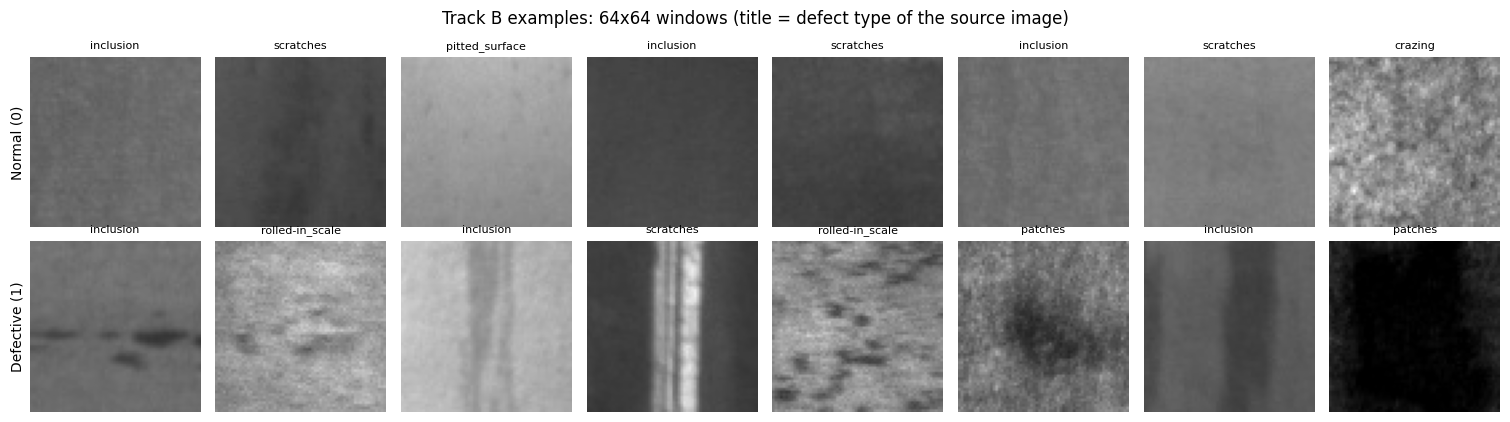

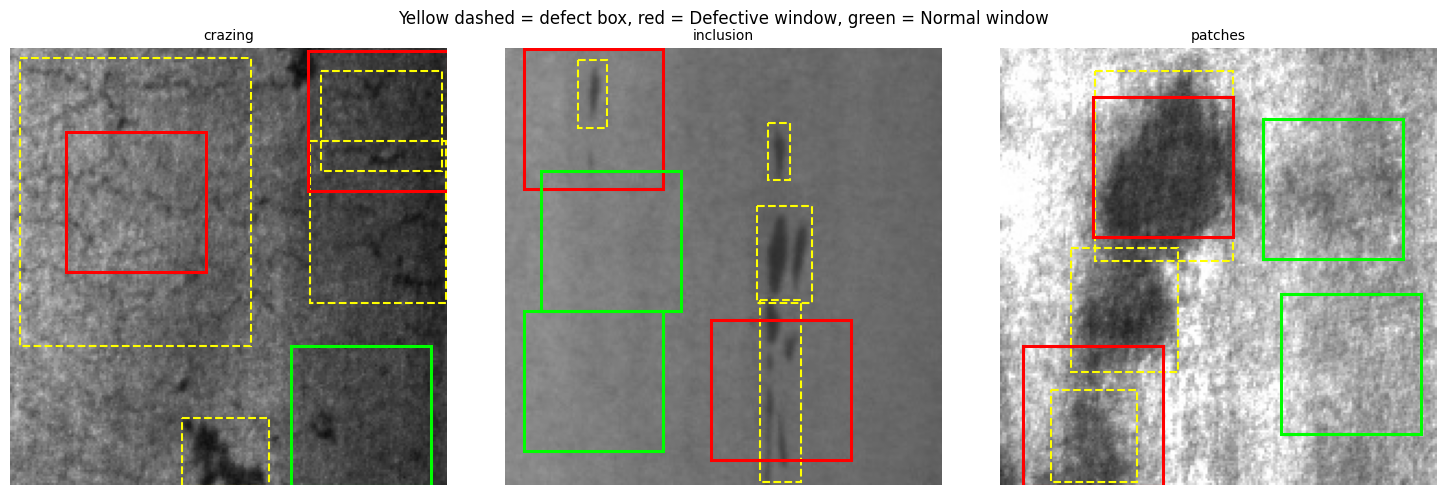

In [13]:
rs = np.random.RandomState(SEED)
n_show = 8
norm_ids = rs.choice(np.where(yw == 0)[0], size=min(n_show, int((yw == 0).sum())), replace=False)
def_ids = rs.choice(np.where(yw == 1)[0], size=min(n_show, int((yw == 1).sum())), replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(1.9 * n_show, 4.3))
for r, ids, name in ((0, norm_ids, "Normal (0)"), (1, def_ids, "Defective (1)")):
    for j in range(n_show):
        if j < len(ids):
            axes[r, j].imshow(WIN_X[ids[j]], cmap="gray", vmin=0, vmax=255)
            axes[r, j].set_title(win_meta.at[ids[j], "src_class"], fontsize=8)
        _clean_axis(axes[r, j])
    axes[r, 0].set_ylabel(name)
plt.suptitle("Track B examples: 64x64 windows (title = defect type of the source image)")
plt.tight_layout(); save_fig("track_b_window_examples"); plt.show()

shown = []
for c in CLASSES:
    for i in meta.index[meta["label"] == c]:
        w = win_meta[win_meta["img_idx"] == i]
        if (w["label"] == 0).any() and (w["label"] == 1).any():
            shown.append(int(i)); break
    if len(shown) == 3:
        break
if shown:
    fig, axes = plt.subplots(1, len(shown), figsize=(5 * len(shown), 5))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, shown):
        ax.imshow(GRAY_NATIVE[i], cmap="gray", vmin=0, vmax=255)
        for x1, y1, x2, y2 in meta.at[i, "boxes"]:
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5, linestyle="--"))
        for _, w in win_meta[win_meta["img_idx"] == i].iterrows():
            ax.add_patch(Rectangle((w["x0"], w["y0"]), WIN, WIN, fill=False, linewidth=2.2, edgecolor="red" if w["label"] == 1 else "lime"))
        ax.set_title(meta.at[i, "label"], fontsize=10)
        _clean_axis(ax)
    plt.suptitle("Yellow dashed = defect box, red = Defective window, green = Normal window")
    plt.tight_layout(); save_fig("track_b_window_placement"); plt.show()

## Task 11: HOG parameter study 

In [14]:
def sq_dists(X):
    '''squared Euclidean distances between all rows of X (float64), via one matrix product'''
    X = np.ascontiguousarray(X, dtype=np.float32)
    G = (X @ X.T).astype(np.float64)
    sq = np.einsum("ij,ij->i", X, X, dtype=np.float64)
    D = sq[:, None] + sq[None, :] - 2.0 * G
    np.maximum(D, 0.0, out=D)
    np.fill_diagonal(D, 0.0)
    return D

def gamma_scale(X):
    '''sklearn's gamma="scale": 1 / (n_features * variance of all entries)'''
    X = np.asarray(X, dtype=np.float32)
    n = X.size
    mean = X.sum(dtype=np.float64) / n
    var = np.einsum("ij,ij->", X, X, dtype=np.float64) / n - mean ** 2
    return 1.0 / (X.shape[1] * var)

def cv_svm_K(K, y, folds, C, class_weight=None):
    '''cross-validate an RBF SVM given the full kernel matrix K over the development samples'''
    accs, f1s, f1d = [], [], []
    binary = len(np.unique(y)) == 2
    for tr, te in folds:
        clf = SVC(kernel="precomputed", C=C, class_weight=class_weight)
        clf.fit(K[np.ix_(tr, tr)], y[tr])
        p = clf.predict(K[np.ix_(te, tr)])
        accs.append(accuracy_score(y[te], p))
        f1s.append(f1_score(y[te], p, average="macro", zero_division=0))
        if binary:
            f1d.append(f1_score(y[te], p, pos_label=1, average="binary", zero_division=0))
    out = dict(acc=float(np.mean(accs)), acc_std=float(np.std(accs)), f1=float(np.mean(f1s)), f1_std=float(np.std(f1s)))
    if binary:
        out["f1_def"] = float(np.mean(f1d))
    return out

FOLDS6 = list(StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED).split(np.zeros(len(y_dev)), y_dev))
FOLDSB = list(StratifiedGroupKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=SEED).split(
    np.zeros(len(yw_dev)), yw_dev, gw[w_dev]))        # grouped by source image: no leakage between folds

SWEEP = RowStore("sweep_results.csv", ["track", "cell", "orient"])

def run_sweep(track, imgs, y, folds, class_weight):
    for cell in CONFIG["cell_sizes"]:
        for orient in CONFIG["orientations"]:
            if SWEEP.done(track=track, cell=cell, orient=orient):
                print(f"[{track}] cell={cell:>2} orient={orient:>2}: already done, skipping")
                continue
            t0 = time.time()
            X = hog_batch(imgs, cell, orient)
            t_ext = time.time() - t0
            D, g = sq_dists(X), gamma_scale(X)
            res = cv_svm_K(np.exp(-g * D), y, folds, CONFIG["sweep_svm_C"], class_weight)
            SWEEP.add(dict(track=track, cell=cell, orient=orient, dim=X.shape[1], acc_mean=res["acc"], acc_std=res["acc_std"],
                           f1_mean=res["f1"], f1_std=res["f1_std"], f1_def=res.get("f1_def", np.nan),
                           extract_s=t_ext, secs=time.time() - t0))
            print(f"[{track}] cell={cell:>2} orient={orient:>2} dim={X.shape[1]:>6}  acc={100 * res['acc']:.2f}  "
                  f"macro-F1={100 * res['f1']:.2f}  ({time.time() - t0:.0f}s)")
            del X, D

print("Track A: 6 defect types, whole images")
run_sweep("6class", IMG128[dev_idx], y_dev, FOLDS6, None)
print("\nTrack B: Normal vs Defective windows")
run_sweep("binary", WIN_X[w_dev], yw_dev, FOLDSB, "balanced")

Track A: 6 defect types, whole images
[6class] cell= 4 orient= 6 dim= 23064  acc=82.55  macro-F1=82.14  (39s)
[6class] cell= 4 orient= 9 dim= 34596  acc=81.18  macro-F1=80.67  (37s)
[6class] cell= 4 orient=12 dim= 46128  acc=83.79  macro-F1=83.42  (41s)
[6class] cell= 8 orient= 6 dim=  5400  acc=88.76  macro-F1=88.62  (9s)
[6class] cell= 8 orient= 9 dim=  8100  acc=88.04  macro-F1=87.88  (11s)
[6class] cell= 8 orient=12 dim= 10800  acc=89.15  macro-F1=89.05  (12s)
[6class] cell=16 orient= 6 dim=  1176  acc=90.85  macro-F1=90.74  (4s)
[6class] cell=16 orient= 9 dim=  1764  acc=90.92  macro-F1=90.81  (5s)
[6class] cell=16 orient=12 dim=  2352  acc=92.29  macro-F1=92.23  (5s)

Track B: Normal vs Defective windows
[binary] cell= 4 orient= 6 dim=  5400  acc=75.84  macro-F1=75.61  (39s)
[binary] cell= 4 orient= 9 dim=  8100  acc=74.53  macro-F1=74.29  (38s)
[binary] cell= 4 orient=12 dim= 10800  acc=73.69  macro-F1=73.34  (33s)
[binary] cell= 8 orient= 6 dim=  1176  acc=76.51  macro-F1=76.36


Track A (6 defect types): 5-fold CV on the development set, SVM-RBF C=10
 cell  orient   dim  acc %  acc std  macro-F1 %  F1 std
    4       6 23064  82.55     1.84       82.14    1.93
    4       9 34596  81.18     2.36       80.67    2.53
    4      12 46128  83.79     1.66       83.42    1.77
    8       6  5400  88.76     1.14       88.62    1.16
    8       9  8100  88.04     1.38       87.88    1.46
    8      12 10800  89.15     1.50       89.05    1.51
   16       6  1176  90.85     0.92       90.74    0.94
   16       9  1764  90.92     0.52       90.81    0.55
   16      12  2352  92.29     0.73       92.23    0.77

Track B (Normal vs Defective windows): 5-fold CV on the development set, SVM-RBF C=10
 cell  orient   dim  acc %  acc std  macro-F1 %  F1 std  F1 defective %
    4       6  5400  75.84     0.89       75.61    0.87           77.93
    4       9  8100  74.53     0.74       74.29    0.66           76.75
    4      12 10800  73.69     0.64       73.34    0.64        

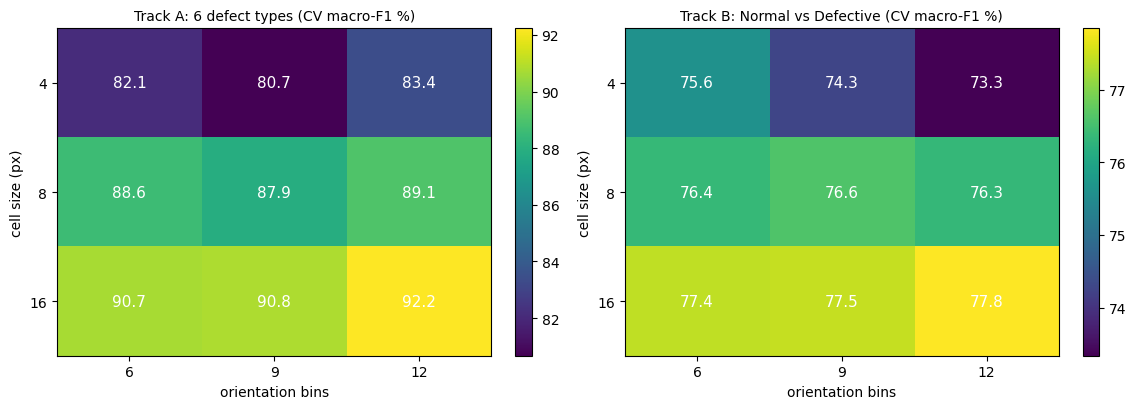

[6class] highest CV macro-F1: cell 16, 12 bins (92.23). Kept (shortest vector within 0.5 points): cell 16, 12 bins, 2,352 features, CV macro-F1 92.23
[binary] highest CV macro-F1: cell 16, 12 bins (77.84). Kept (shortest vector within 0.5 points): cell 16, 6 bins, 216 features, CV macro-F1 77.41


In [15]:
def sweep_table(track):
    d = SWEEP.where(track=track).copy()
    d["cell"], d["orient"], d["dim"] = d["cell"].astype(int), d["orient"].astype(int), d["dim"].astype(int)
    d = d.sort_values(["cell", "orient"])
    out = pd.DataFrame({"cell": d["cell"], "orient": d["orient"], "dim": d["dim"],
                        "acc %": (100 * d["acc_mean"]).round(2), "acc std": (100 * d["acc_std"]).round(2),
                        "macro-F1 %": (100 * d["f1_mean"]).round(2), "F1 std": (100 * d["f1_std"]).round(2)})
    if track == "binary":
        out["F1 defective %"] = (100 * d["f1_def"]).round(2)
    return out

for track, title in (("6class", "Track A (6 defect types)"), ("binary", "Track B (Normal vs Defective windows)")):
    print(f"\n{title}: 5-fold CV on the development set, SVM-RBF C={CONFIG['sweep_svm_C']}")
    print(sweep_table(track).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for ax, track, title in zip(axes, ("6class", "binary"), ("Track A: 6 defect types (CV macro-F1 %)", "Track B: Normal vs Defective (CV macro-F1 %)")):
    d = SWEEP.where(track=track).copy()
    d["cell"], d["orient"] = d["cell"].astype(int), d["orient"].astype(int)
    piv = (100 * d.pivot(index="cell", columns="orient", values="f1_mean")).reindex(index=CONFIG["cell_sizes"], columns=CONFIG["orientations"])
    im = ax.imshow(piv.to_numpy(), cmap="viridis", aspect="auto")
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
    ax.set_xlabel("orientation bins"); ax.set_ylabel("cell size (px)"); ax.set_title(title, fontsize=10)
    for (r, c_), v in np.ndenumerate(piv.to_numpy()):
        ax.text(c_, r, f"{v:.1f}", ha="center", va="center", color="white", fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); save_fig("task11_hog_parameter_heatmaps"); plt.show()

def pick_best(track):
    d = SWEEP.where(track=track).copy()
    d["cell"], d["orient"], d["dim"] = d["cell"].astype(int), d["orient"].astype(int), d["dim"].astype(int)
    top = d.sort_values(["f1_mean", "acc_mean"], ascending=False).iloc[0]
    ok = d[d["f1_mean"] >= top["f1_mean"] - CONFIG["parsimony_tol"]]
    best = ok.sort_values(["dim", "f1_mean"], ascending=[True, False]).iloc[0]
    rec = dict(cell=int(best["cell"]), orient=int(best["orient"]), dim=int(best["dim"]), f1_mean=float(best["f1_mean"]),
               top_cell=int(top["cell"]), top_orient=int(top["orient"]), top_f1=float(top["f1_mean"]))
    EXTRAS.set(f"best_hog_{track}", rec)
    return rec

for track in ("6class", "binary"):
    b = pick_best(track)
    print(f"[{track}] highest CV macro-F1: cell {b['top_cell']}, {b['top_orient']} bins ({100 * b['top_f1']:.2f}). "
          f"Kept (shortest vector within {100 * CONFIG['parsimony_tol']:.1f} points): cell {b['cell']}, {b['orient']} bins, "
          f"{b['dim']:,} features, CV macro-F1 {100 * b['f1_mean']:.2f}")

## Tasks 6 to 10: Train, tune and compare the classifiers

In [16]:
SLUG = lambda s: re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")
CLF_NAMES = ["SVM (RBF)", "SVM (linear)", "Random forest", "k-NN", "Logistic regression"]
TRACK = {}

def setup_track(name, imgs_dev, imgs_test, y_dev_, y_test_, folds, class_weight, c_grid, g_grid, class_names):
    best = EXTRAS.get(f"best_hog_{name}")
    cell, orient = best["cell"], best["orient"]
    TRACK[name] = dict(cell=cell, orient=orient, y_dev=y_dev_, y_test=y_test_, folds=folds, cw=class_weight,
                       c_grid=c_grid, g_grid=g_grid, names=class_names,
                       Xdev=Lazy(lambda: hog_batch(imgs_dev, cell, orient)),
                       Xtest=Lazy(lambda: hog_batch(imgs_test, cell, orient)))

setup_track("6class", IMG128[dev_idx], IMG128[test_idx], y_dev, y_test, FOLDS6, None,
            CONFIG["svm_C_grid"], CONFIG["svm_gamma_mult_grid"], CLASSES)
setup_track("binary", WIN_X[w_dev], WIN_X[w_test], yw_dev, yw_test, FOLDSB, "balanced",
            CONFIG["svm_C_grid_bin"], CONFIG["svm_gamma_mult_grid_bin"], ["Normal", "Defective"])

TUNE = RowStore("tuning_results.csv", ["track", "clf", "param"])

def tune_svm_rbf(track):
    key = f"tuned_{track}_svm_rbf"
    if EXTRAS.has(key):
        print(f"[{track}] SVM (RBF): tuning already done ->", EXTRAS.get(key)); return
    T = TRACK[track]
    X = T["Xdev"].get()
    D, g0 = sq_dists(X), gamma_scale(X)
    for gm in T["g_grid"]:
        K = np.exp(-gm * g0 * D)
        for C in T["c_grid"]:
            param = json.dumps({"C": C, "gmult": gm}, sort_keys=True)
            if TUNE.done(track=track, clf="SVM (RBF)", param=param):
                continue
            res = cv_svm_K(K, T["y_dev"], T["folds"], C, T["cw"])
            TUNE.add(dict(track=track, clf="SVM (RBF)", param=param, f1_mean=res["f1"], f1_std=res["f1_std"],
                          acc_mean=res["acc"], acc_std=res["acc_std"]))
            print(f"[{track}] SVM (RBF)  C={C:<5} gamma x{gm:<5}  CV macro-F1={100 * res['f1']:.2f}  acc={100 * res['acc']:.2f}")
    d = TUNE.where(track=track, clf="SVM (RBF)")
    best = d.sort_values(["f1_mean", "acc_mean"], ascending=False).iloc[0]
    p = json.loads(best["param"])
    EXTRAS.set(key, dict(C=p["C"], gmult=p["gmult"], gamma=float(p["gmult"] * g0),
                         cv_f1=float(best["f1_mean"]), cv_acc=float(best["acc_mean"])))
    print(f"[{track}] SVM (RBF) best:", EXTRAS.get(key))

def cv_score_clf(make, X, y, folds):
    f1s, accs = [], []
    for tr, te in folds:
        clf = make()
        clf.fit(X[tr], y[tr])
        p = clf.predict(X[te])
        f1s.append(f1_score(y[te], p, average="macro", zero_division=0))
        accs.append(accuracy_score(y[te], p))
    return float(np.mean(f1s)), float(np.mean(accs))

def tune_generic(track, clf_name, tag, grid, make, max_folds=None):
    key = f"tuned_{track}_{tag}"
    if EXTRAS.has(key):
        print(f"[{track}] {clf_name}: tuning already done ->", EXTRAS.get(key)); return
    T = TRACK[track]
    folds = T["folds"] if max_folds is None else T["folds"][:max_folds]
    X = None
    for prm in grid:
        param = json.dumps(prm, sort_keys=True)
        if TUNE.done(track=track, clf=clf_name, param=param):
            continue
        if X is None:
            X = T["Xdev"].get()
        t0 = time.time()
        f1m, accm = cv_score_clf(lambda: make(prm), X, T["y_dev"], folds)
        TUNE.add(dict(track=track, clf=clf_name, param=param, f1_mean=f1m, acc_mean=accm, secs=time.time() - t0))
        print(f"[{track}] {clf_name:<20} {param:<14} CV macro-F1={100 * f1m:.2f}  acc={100 * accm:.2f}  ({time.time() - t0:.0f}s)")
    d = TUNE.where(track=track, clf=clf_name)
    best = d.sort_values(["f1_mean", "acc_mean"], ascending=False).iloc[0]
    EXTRAS.set(key, {**json.loads(best["param"]), "cv_f1": float(best["f1_mean"]), "cv_acc": float(best["acc_mean"]),
                     "folds_used": len(folds)})

for track in ("6class", "binary"):
    T = TRACK[track]
    print(f"\n=== {track}: HOG cell {T['cell']}, {T['orient']} bins, {EXTRAS.get('best_hog_' + track)['dim']:,} features ===")
    tune_svm_rbf(track)
    tune_generic(track, "SVM (linear)", "svm_linear", [{"C": c} for c in CONFIG["linsvm_C_grid"]],
                 lambda p: LinearSVC(C=p["C"], dual=True, max_iter=5000, class_weight=T["cw"], random_state=SEED))
    tune_generic(track, "k-NN", "knn", [{"k": k} for k in CONFIG["knn_k_grid"]],
                 lambda p: KNeighborsClassifier(n_neighbors=p["k"], weights="distance"))
    tune_generic(track, "Logistic regression", "logreg", [{"C": c} for c in CONFIG["lr_C_grid"]],
                 lambda p: LogisticRegression(C=p["C"], max_iter=300, tol=1e-3, class_weight=T["cw"]), max_folds=1)

rows = []
for track in ("6class", "binary"):
    for name, tag in (("SVM (RBF)", "svm_rbf"), ("SVM (linear)", "svm_linear"), ("k-NN", "knn"), ("Logistic regression", "logreg")):
        p = EXTRAS.get(f"tuned_{track}_{tag}")
        shown = {k: (round(v, 6) if isinstance(v, float) else v) for k, v in p.items() if k not in ("cv_f1", "cv_acc", "folds_used")}
        rows.append(dict(track=track, classifier=name, chosen=json.dumps(shown), cv_macro_F1=round(100 * p["cv_f1"], 2)))
print("\nChosen settings (CV macro-F1 in %):")
print(pd.DataFrame(rows).to_string(index=False))


=== 6class: HOG cell 16, 12 bins, 2,352 features ===
[6class] SVM (RBF)  C=1     gamma x0.25   CV macro-F1=88.81  acc=88.95
[6class] SVM (RBF)  C=10    gamma x0.25   CV macro-F1=90.03  acc=90.13
[6class] SVM (RBF)  C=100   gamma x0.25   CV macro-F1=89.83  acc=89.93
[6class] SVM (RBF)  C=1000  gamma x0.25   CV macro-F1=89.83  acc=89.93
[6class] SVM (RBF)  C=1     gamma x0.5    CV macro-F1=90.71  acc=90.78
[6class] SVM (RBF)  C=10    gamma x0.5    CV macro-F1=90.99  acc=91.05
[6class] SVM (RBF)  C=100   gamma x0.5    CV macro-F1=90.99  acc=91.05
[6class] SVM (RBF)  C=1000  gamma x0.5    CV macro-F1=90.99  acc=91.05
[6class] SVM (RBF)  C=1     gamma x1.0    CV macro-F1=91.43  acc=91.50
[6class] SVM (RBF)  C=10    gamma x1.0    CV macro-F1=92.23  acc=92.29
[6class] SVM (RBF)  C=100   gamma x1.0    CV macro-F1=92.23  acc=92.29
[6class] SVM (RBF)  C=1000  gamma x1.0    CV macro-F1=92.23  acc=92.29
[6class] SVM (RBF)  C=1     gamma x2.0    CV macro-F1=91.39  acc=91.50
[6class] SVM (RBF)  C=1

In [17]:
# ---- final fit on the whole development set, one score on the test set ----
def metrics_multi(y, p):
    pr, rc, f1, _ = precision_recall_fscore_support(y, p, average="macro", zero_division=0)
    return dict(acc=accuracy_score(y, p), prec=pr, rec=rc, f1=f1, bal_acc=balanced_accuracy_score(y, p))

def metrics_bin(y, p, score=None):
    d = metrics_multi(y, p)
    pr, rc, f1, _ = precision_recall_fscore_support(y, p, average="binary", pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, p, labels=[0, 1]).ravel()
    d.update(prec_def=pr, rec_def=rc, f1_def=f1, fpr=fp / max(fp + tn, 1), fnr=fn / max(fn + tp, 1))
    if score is not None and len(np.unique(y)) == 2:
        d["auc"] = roc_auc_score(y, score)
    return d

def build_clf(track, name):
    T = TRACK[track]
    cw = T["cw"]
    if name == "SVM (RBF)":
        p = EXTRAS.get(f"tuned_{track}_svm_rbf")
        return SVC(kernel="rbf", C=p["C"], gamma=p["gamma"], probability=True, class_weight=cw, random_state=SEED)
    if name == "SVM (linear)":
        p = EXTRAS.get(f"tuned_{track}_svm_linear")
        return LinearSVC(C=p["C"], dual=True, max_iter=5000, class_weight=cw, random_state=SEED)
    if name == "Random forest":
        return RandomForestClassifier(n_estimators=CONFIG["rf_trees"], class_weight=("balanced_subsample" if cw else None),
                                      n_jobs=CONFIG["n_jobs"], random_state=SEED)
    if name == "k-NN":
        p = EXTRAS.get(f"tuned_{track}_knn")
        return KNeighborsClassifier(n_neighbors=int(p["k"]), weights="distance")
    if name == "Logistic regression":
        p = EXTRAS.get(f"tuned_{track}_logreg")
        return LogisticRegression(C=p["C"], max_iter=300, tol=1e-3, class_weight=cw)
    raise ValueError(name)

def model_path(track, name):
    return os.path.join(MODEL_DIR, f"{track}__{SLUG(name)}.joblib")

def get_or_fit(track, name):
    '''load the fitted model from the checkpoint folder, or fit it on the development set (k-NN is refit, it is instant)'''
    path = model_path(track, name)
    if name != "k-NN" and os.path.exists(path):
        return joblib.load(path), EXTRAS.get(f"fit_s_{track}_{SLUG(name)}")
    T = TRACK[track]
    clf = build_clf(track, name)
    t0 = time.time()
    clf.fit(T["Xdev"].get(), T["y_dev"])
    fit_s = time.time() - t0
    EXTRAS.set(f"fit_s_{track}_{SLUG(name)}", fit_s)
    if name != "k-NN":
        joblib.dump(clf, path, compress=3)
    return clf, fit_s

CMP = RowStore("comparison_results.csv", ["track", "clf"])

def evaluate_all(track):
    T = TRACK[track]
    for name in CLF_NAMES:
        if CMP.done(track=track, clf=name):
            print(f"[{track}] {name}: already evaluated, skipping")
            continue
        print(f"[{track}] fitting {name} ...", flush=True)
        clf, fit_s = get_or_fit(track, name)
        Xte = T["Xtest"].get()
        t0 = time.time()
        pred = clf.predict(Xte)
        pred_ms = 1000 * (time.time() - t0) / len(Xte)
        score = None
        if track == "binary":
            score = clf.decision_function(Xte) if hasattr(clf, "decision_function") else clf.predict_proba(Xte)[:, 1]
            m = metrics_bin(T["y_test"], pred, score)
            if name == "SVM (RBF)":
                EXTRAS.set("pdef_binary_test", np.round(clf.predict_proba(Xte)[:, 1], 6).tolist())
        else:
            m = metrics_multi(T["y_test"], pred)
        EXTRAS.set(f"pred_{track}_{SLUG(name)}", pred.tolist())
        if score is not None:
            EXTRAS.set(f"score_{track}_{SLUG(name)}", np.round(score, 6).tolist())
        CMP.add(dict(track=track, clf=name, fit_s=fit_s, predict_ms_per_sample=pred_ms, **m))
        print(f"[{track}] {name:<20} test accuracy={100 * m['acc']:.2f}  macro-F1={100 * m['f1']:.2f}  (fit {fit_s if fit_s is None else round(fit_s, 1)}s)")

evaluate_all("6class")
evaluate_all("binary")

[6class] fitting SVM (RBF) ...
[6class] SVM (RBF)            test accuracy=92.96  macro-F1=92.89  (fit 8.1s)
[6class] fitting SVM (linear) ...
[6class] SVM (linear)         test accuracy=77.41  macro-F1=76.59  (fit 3.3s)
[6class] fitting Random forest ...
[6class] Random forest        test accuracy=89.26  macro-F1=89.14  (fit 17.0s)
[6class] fitting k-NN ...
[6class] k-NN                 test accuracy=82.59  macro-F1=79.97  (fit 0.0s)
[6class] fitting Logistic regression ...
[6class] Logistic regression  test accuracy=81.11  macro-F1=80.90  (fit 2.3s)
[binary] fitting SVM (RBF) ...
[binary] SVM (RBF)            test accuracy=78.11  macro-F1=77.96  (fit 14.0s)
[binary] fitting SVM (linear) ...
[binary] SVM (linear)         test accuracy=74.74  macro-F1=74.59  (fit 5.9s)
[binary] fitting Random forest ...
[binary] Random forest        test accuracy=79.16  macro-F1=78.75  (fit 22.9s)
[binary] fitting k-NN ...
[binary] k-NN                 test accuracy=72.18  macro-F1=72.07  (fit 0.0s)
[b

###  Track A: six defect types 

Track A (6 defect types): all five classifiers on the test set (metrics in %)
         classifier  accuracy %  precision (macro) %  recall (macro) %  F1 (macro) %  balanced acc %  fit s  predict ms/sample
          SVM (RBF)       92.96                92.99             92.96         92.89           92.96    8.1               2.65
       SVM (linear)       77.41                77.25             77.41         76.59           77.41    3.3               0.01
      Random forest       89.26                89.27             89.26         89.14           89.26   17.0               0.32
               k-NN       82.59                87.18             82.59         79.97           82.59    0.0               0.21
Logistic regression       81.11                81.14             81.11         80.90           81.11    2.3               0.02


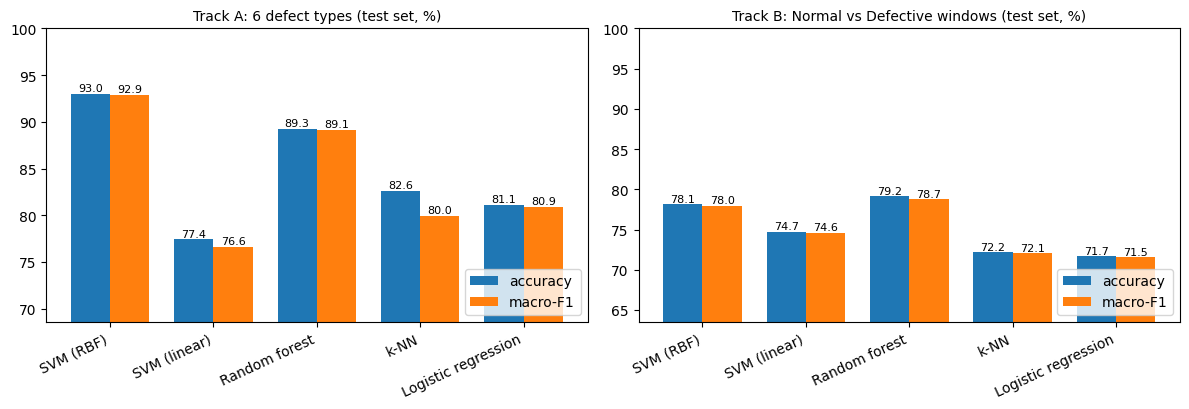


Best classifier other than the RBF SVM on the test set: Random forest


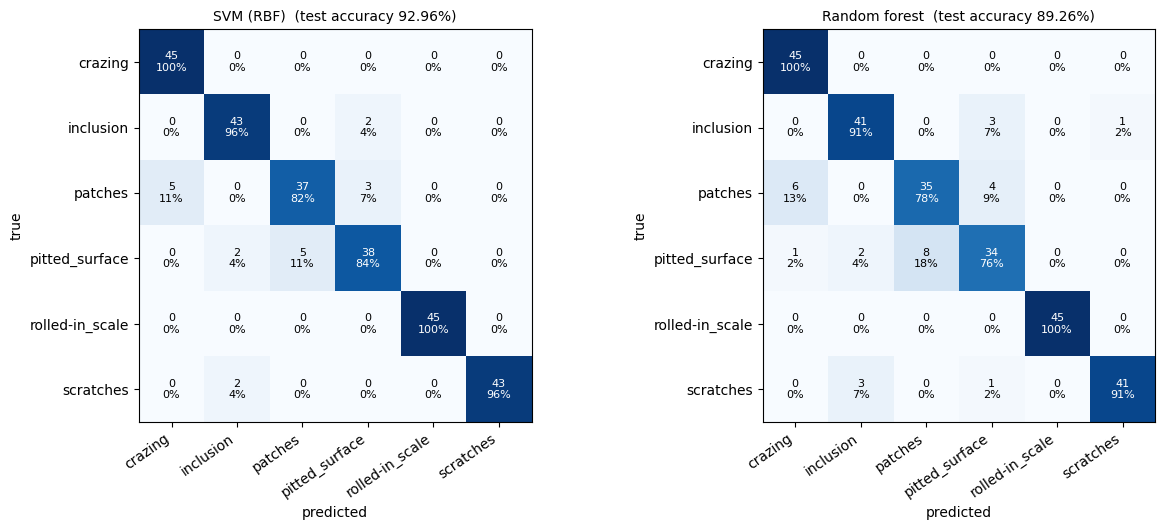


Classification report: SVM (RBF) (6class, test set)
                 precision    recall  f1-score   support

        crazing      0.900     1.000     0.947        45
      inclusion      0.915     0.956     0.935        45
        patches      0.881     0.822     0.851        45
 pitted_surface      0.884     0.844     0.864        45
rolled-in_scale      1.000     1.000     1.000        45
      scratches      1.000     0.956     0.977        45

       accuracy                          0.930       270
      macro avg      0.930     0.930     0.929       270
   weighted avg      0.930     0.930     0.929       270


Classification report: Random forest (6class, test set)
                 precision    recall  f1-score   support

        crazing      0.865     1.000     0.928        45
      inclusion      0.891     0.911     0.901        45
        patches      0.814     0.778     0.795        45
 pitted_surface      0.810     0.756     0.782        45
rolled-in_scale      1.000     

In [18]:
def comparison_table(track):
    d = CMP.where(track=track).copy().set_index("clf").loc[CLF_NAMES].reset_index()
    cols = ["acc", "bal_acc", "prec_def", "rec_def", "f1_def", "f1", "fnr", "fpr", "auc"] if track == "binary" else ["acc", "prec", "rec", "f1", "bal_acc"]
    out = pd.DataFrame({"classifier": d["clf"]})
    names = dict(acc="accuracy %", prec="precision (macro) %", rec="recall (macro) %", f1="F1 (macro) %", bal_acc="balanced acc %",
                 prec_def="precision (Defective) %", rec_def="recall (Defective) %", f1_def="F1 (Defective) %",
                 fpr="false reject %", fnr="missed defect %", auc="AUC %")
    for c in cols:
        out[names[c]] = (100 * d[c]).round(2)
    out["fit s"] = d["fit_s"].round(1)
    out["predict ms/sample"] = d["predict_ms_per_sample"].round(2)
    return out

def comparison_figure(fname):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, track, title in zip(axes, ("6class", "binary"), ("Track A: 6 defect types", "Track B: Normal vs Defective windows")):
        d = CMP.where(track=track).set_index("clf").loc[CLF_NAMES]
        x = np.arange(len(CLF_NAMES)); w = 0.38
        ax.bar(x - w / 2, 100 * d["acc"], w, label="accuracy"); ax.bar(x + w / 2, 100 * d["f1"], w, label="macro-F1")
        lo = max(0, 100 * min(d["acc"].min(), d["f1"].min()) - 8)
        ax.set_ylim(lo, 100); ax.set_xticks(x); ax.set_xticklabels(CLF_NAMES, rotation=25, ha="right")
        for xi, (a, f) in enumerate(zip(100 * d["acc"], 100 * d["f1"])):
            ax.text(xi - w / 2, a + 0.3, f"{a:.1f}", ha="center", fontsize=8); ax.text(xi + w / 2, f + 0.3, f"{f:.1f}", ha="center", fontsize=8)
        ax.set_title(title + " (test set, %)", fontsize=10); ax.legend(loc="lower right")
    plt.tight_layout(); save_fig(fname); plt.show()

def best_other(track):
    d = CMP.where(track=track)
    return d[d["clf"] != "SVM (RBF)"].sort_values("f1", ascending=False).iloc[0]["clf"]

def cm_figure(track, names, fname):
    T = TRACK[track]
    cls_names = T["names"]
    fig, axes = plt.subplots(1, len(names), figsize=(6.4 * len(names), 5.4))
    for ax, n in zip(np.atleast_1d(axes), names):
        pred = np.array(EXTRAS.get(f"pred_{track}_{SLUG(n)}"))
        cm = confusion_matrix(T["y_test"], pred, labels=list(range(len(cls_names))))
        cmn = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(cls_names))); ax.set_xticklabels(cls_names, rotation=35, ha="right")
        ax.set_yticks(range(len(cls_names))); ax.set_yticklabels(cls_names)
        for (r, c_), v in np.ndenumerate(cm):
            ax.text(c_, r, f"{v}\n{100 * cmn[r, c_]:.0f}%", ha="center", va="center", fontsize=8,
                    color="white" if cmn[r, c_] > 0.5 else "black")
        ax.set_title(f"{n}  (test accuracy {100 * accuracy_score(T['y_test'], pred):.2f}%)", fontsize=10)
        ax.set_xlabel("predicted"); ax.set_ylabel("true")
    plt.tight_layout(); save_fig(fname); plt.show()

def print_reports(track, names):
    T = TRACK[track]
    for n in names:
        pred = np.array(EXTRAS.get(f"pred_{track}_{SLUG(n)}"))
        print(f"\nClassification report: {n} ({track}, test set)")
        print(classification_report(T["y_test"], pred, target_names=T["names"], digits=3, zero_division=0))

print("Track A (6 defect types): all five classifiers on the test set (metrics in %)")
print(comparison_table("6class").to_string(index=False))
comparison_figure("task8_classifier_comparison")

OTHER6 = best_other("6class")
EXTRAS.set("second_classifier_6class", OTHER6)
print(f"\nBest classifier other than the RBF SVM on the test set: {OTHER6}")
cm_figure("6class", ["SVM (RBF)", OTHER6], "task9_confusion_matrices_track_a")
print_reports("6class", ["SVM (RBF)", OTHER6])

RBF SVM misclassified 19 of 270 test images


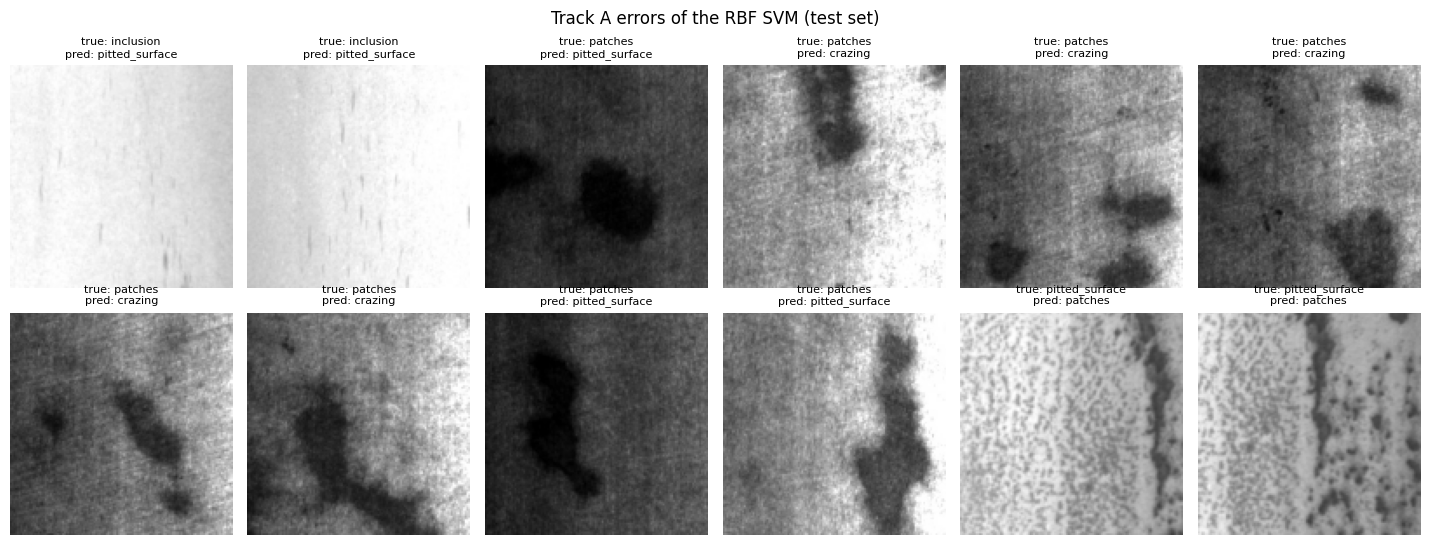

In [19]:
# Which test images does the RBF SVM get wrong? (Track A)
pred = np.array(EXTRAS.get("pred_6class_svm_rbf"))
wrong = np.where(pred != y_test)[0]
print(f"RBF SVM misclassified {len(wrong)} of {len(y_test)} test images")
if len(wrong):
    n_show, ncols = min(12, len(wrong)), 6
    nrows = int(np.ceil(n_show / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.4 * ncols, 2.8 * nrows))
    for k, ax in enumerate(np.atleast_2d(axes).ravel()):
        if k < n_show:
            j = wrong[k]
            ax.imshow(IMG128[test_idx[j]], cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"true: {CLASSES[y_test[j]]}\npred: {CLASSES[pred[j]]}", fontsize=8)
        _clean_axis(ax)
    plt.suptitle("Track A errors of the RBF SVM (test set)")
    plt.tight_layout(); save_fig("task9_track_a_errors"); plt.show()

### Track B: Normal vs Defective windows

Track B (Normal vs Defective windows): all five classifiers on the test set (metrics in %)
         classifier  accuracy %  balanced acc %  precision (Defective) %  recall (Defective) %  F1 (Defective) %  F1 (macro) %  missed defect %  false reject %  AUC %  fit s  predict ms/sample
          SVM (RBF)       78.11           78.14                    81.72                 77.94             79.78         77.96            22.06           21.67  87.13   14.0               0.78
       SVM (linear)       74.74           74.78                    78.84                 74.37             76.54         74.59            25.63           24.80  83.89    5.9               0.00
      Random forest       79.16           78.57                    79.52                 84.03             81.72         78.75            15.97           26.89  89.42   22.9               0.10
               k-NN       72.18           73.72                    86.02                 59.45             70.31         72.07           

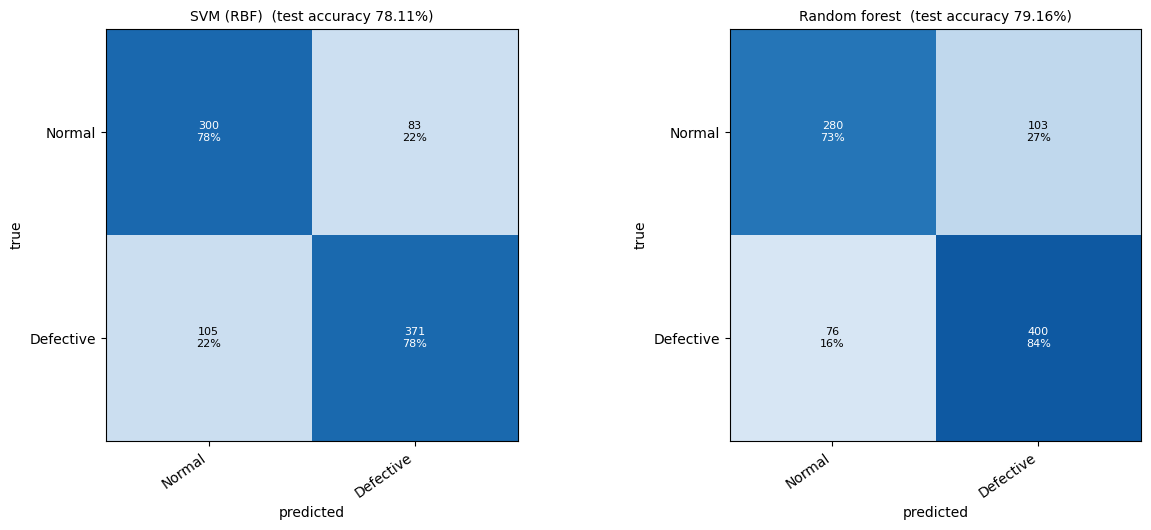


Classification report: SVM (RBF) (binary, test set)
              precision    recall  f1-score   support

      Normal      0.741     0.783     0.761       383
   Defective      0.817     0.779     0.798       476

    accuracy                          0.781       859
   macro avg      0.779     0.781     0.780       859
weighted avg      0.783     0.781     0.782       859


Classification report: Random forest (binary, test set)
              precision    recall  f1-score   support

      Normal      0.787     0.731     0.758       383
   Defective      0.795     0.840     0.817       476

    accuracy                          0.792       859
   macro avg      0.791     0.786     0.787       859
weighted avg      0.791     0.792     0.791       859



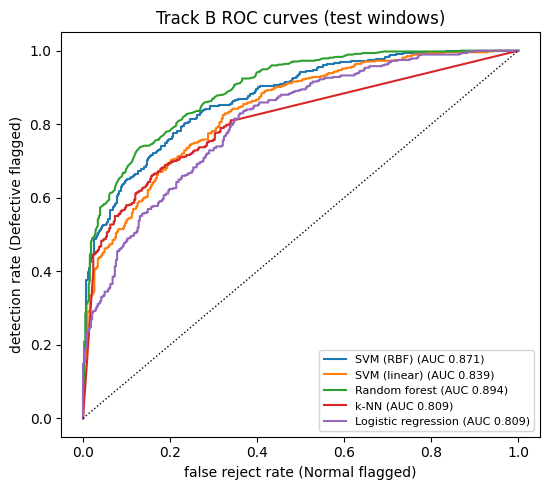


Reject threshold on P(defect), RBF SVM, test windows (%):
 threshold  detection_rate  missed_defect  false_reject  precision
       0.1           99.37           0.63         75.72      61.99
       0.3           91.60           8.40         47.52      70.55
       0.5           80.67          19.33         24.54      80.33
       0.7           65.34          34.66         10.70      88.35
       0.9           39.92          60.08          1.31      97.44


In [20]:
print("Track B (Normal vs Defective windows): all five classifiers on the test set (metrics in %)")
print(comparison_table("binary").to_string(index=False))

OTHERB = best_other("binary")
EXTRAS.set("second_classifier_binary", OTHERB)
print(f"\nBest classifier other than the RBF SVM on the test set: {OTHERB}")
cm_figure("binary", ["SVM (RBF)", OTHERB], "task9_confusion_matrices_track_b")
print_reports("binary", ["SVM (RBF)", OTHERB])

fig, ax = plt.subplots(figsize=(5.6, 5))
for n in CLF_NAMES:
    s = np.array(EXTRAS.get(f"score_binary_{SLUG(n)}"))
    fpr_, tpr_, _ = roc_curve(yw_test, s)
    ax.plot(fpr_, tpr_, label=f"{n} (AUC {roc_auc_score(yw_test, s):.3f})")
ax.plot([0, 1], [0, 1], "k:", linewidth=1)
ax.set_xlabel("false reject rate (Normal flagged)"); ax.set_ylabel("detection rate (Defective flagged)")
ax.set_title("Track B ROC curves (test windows)"); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); save_fig("task9_track_b_roc"); plt.show()

# What the REJECT threshold does (RBF SVM, calibrated P(defect)): the knob a factory would tune
pdef = np.array(EXTRAS.get("pdef_binary_test"))
rows = []
for tau in (0.1, 0.3, 0.5, 0.7, 0.9):
    p_ = (pdef >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(yw_test, p_, labels=[0, 1]).ravel()
    rows.append(dict(threshold=tau, detection_rate=round(100 * tp / max(tp + fn, 1), 2), missed_defect=round(100 * fn / max(tp + fn, 1), 2),
                     false_reject=round(100 * fp / max(fp + tn, 1), 2), precision=round(100 * tp / max(tp + fp, 1), 2)))
THRESH_TABLE = pd.DataFrame(rows)
EXTRAS.set("threshold_table_binary", THRESH_TABLE.to_dict("records"))
print("\nReject threshold on P(defect), RBF SVM, test windows (%):")
print(THRESH_TABLE.to_string(index=False))

##  Task 12: Robustness to realistic imaging conditions

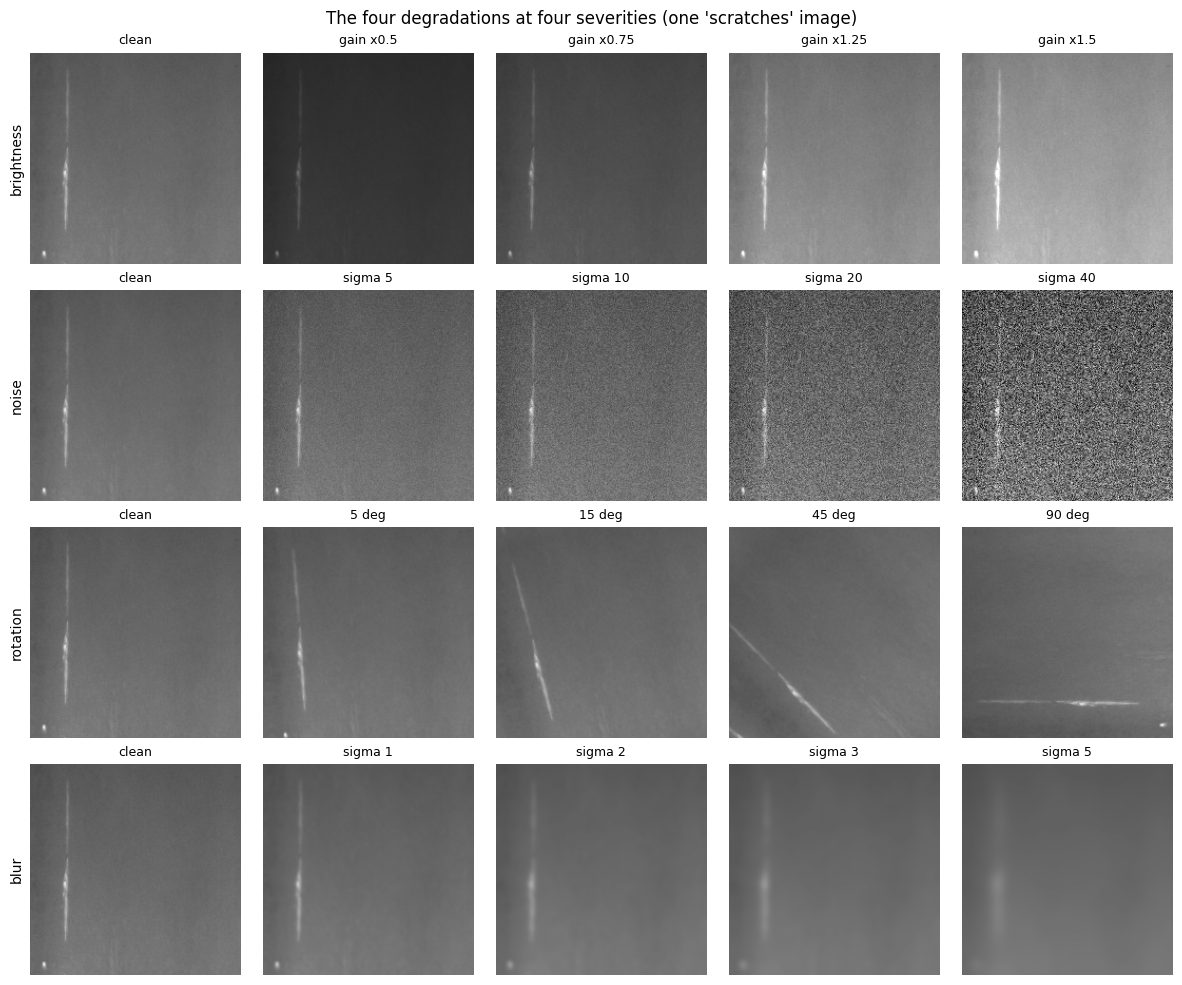

In [21]:
def perturb(img, cond, level, rng):
    if cond == "clean":
        return img
    if cond == "brightness":
        return np.clip(img.astype(np.float32) * level, 0, 255).astype(np.uint8)
    if cond == "noise":
        return np.clip(img.astype(np.float32) + rng.normal(0, level, img.shape), 0, 255).astype(np.uint8)
    if cond == "rotation":
        h, w = img.shape
        M = cv2.getRotationMatrix2D((w / 2.0, h / 2.0), float(level), 1.0)
        return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    if cond == "blur":
        return cv2.GaussianBlur(img, (0, 0), sigmaX=float(level))
    raise ValueError(cond)

CONDS = [("clean", 0)] + [(c, l) for c, ls in CONFIG["robust_levels"].items() for l in ls]
LV = lambda level: f"{level:g}"
UNIT = {"brightness": "gain x{}", "noise": "sigma {}", "rotation": "{} deg", "blur": "sigma {}"}

base = GRAY_NATIVE[REP_IDX[demo_c]]
fig, axes = plt.subplots(len(CONFIG["robust_levels"]), 5, figsize=(12, 2.5 * len(CONFIG["robust_levels"])))
for r, (cond, levels) in enumerate(CONFIG["robust_levels"].items()):
    axes[r, 0].imshow(base, cmap="gray", vmin=0, vmax=255); axes[r, 0].set_title("clean", fontsize=9); axes[r, 0].set_ylabel(cond)
    for c_, lv in enumerate(levels, start=1):
        axes[r, c_].imshow(perturb(base, cond, lv, np.random.RandomState(SEED + 7)), cmap="gray", vmin=0, vmax=255)
        axes[r, c_].set_title(UNIT[cond].format(LV(lv)), fontsize=9)
    for c_ in range(5):
        _clean_axis(axes[r, c_])
plt.suptitle(f"The four degradations at four severities (one '{demo_c}' image)")
plt.tight_layout(); save_fig("task12_perturbation_examples"); plt.show()

In [22]:
ROB = RowStore("robustness_results.csv", ["track", "clf", "cond", "level"], str_cols=("level",))

def run_robustness(track):
    T = TRACK[track]
    base_imgs = [GRAY_NATIVE[i] for i in test_idx] if track == "6class" else list(WIN_X[w_test])
    models = {}
    for cond, level in CONDS:
        lv = LV(level)
        need = [n for n in CLF_NAMES if not ROB.done(track=track, clf=n, cond=cond, level=lv)]
        if not need:
            continue
        rng = np.random.RandomState(SEED + 7)
        pert = [perturb(im, cond, level, rng) for im in base_imgs]
        if track == "6class":
            pert = [preprocess_full(im) for im in pert]
        X = hog_batch(np.stack(pert), T["cell"], T["orient"])
        for n in need:
            if n not in models:
                models[n] = get_or_fit(track, n)[0]
            pred = models[n].predict(X)
            m = metrics_multi(T["y_test"], pred) if track == "6class" else metrics_bin(T["y_test"], pred)
            ROB.add(dict(track=track, clf=n, cond=cond, level=lv, **m))
        print(f"[{track}] {cond:<10} {lv:<5} done")

run_robustness("6class")
run_robustness("binary")

for track in ("6class", "binary"):          # integrity check: the "clean" row must equal the Section 8 test result
    for n in CLF_NAMES:
        a = ROB.where(track=track, clf=n, cond="clean", level="0").iloc[0]["acc"]
        b = CMP.where(track=track, clf=n).iloc[0]["acc"]
        if abs(a - b) > 1e-9:
            print(f"WARNING: clean robustness accuracy differs from the Section 8 result for {track} / {n}: {a} vs {b}")
print("Integrity check done: clean robustness rows match the Section 8 test results.")

[6class] clean      0     done
[6class] brightness 0.5   done
[6class] brightness 0.75  done
[6class] brightness 1.25  done
[6class] brightness 1.5   done
[6class] noise      5     done
[6class] noise      10    done
[6class] noise      20    done
[6class] noise      40    done
[6class] rotation   5     done
[6class] rotation   15    done
[6class] rotation   45    done
[6class] rotation   90    done
[6class] blur       1     done
[6class] blur       2     done
[6class] blur       3     done
[6class] blur       5     done
[binary] clean      0     done
[binary] brightness 0.5   done
[binary] brightness 0.75  done
[binary] brightness 1.25  done
[binary] brightness 1.5   done
[binary] noise      5     done
[binary] noise      10    done
[binary] noise      20    done
[binary] noise      40    done
[binary] rotation   5     done
[binary] rotation   15    done
[binary] rotation   45    done
[binary] rotation   90    done
[binary] blur       1     done
[binary] blur       2     done
[binary]


6class | SVM (RBF) | clean: accuracy 92.96%, macro-F1 92.89%   (d_ = change vs clean, in points)
 condition      level  accuracy  d_accuracy    F1   d_F1
brightness  gain x0.5     84.81       -8.15 84.63  -8.26
brightness gain x0.75     92.59       -0.37 92.40  -0.49
brightness gain x1.25     84.81       -8.15 84.81  -8.08
brightness  gain x1.5     68.15      -24.81 67.71 -25.18
     noise    sigma 5     80.00      -12.96 79.59 -13.31
     noise   sigma 10     57.78      -35.19 53.00 -39.90
     noise   sigma 20     30.00      -62.96 21.88 -71.02
     noise   sigma 40     17.78      -75.19  6.68 -86.22
  rotation      5 deg     93.70        0.74 93.68   0.78
  rotation     15 deg     91.48       -1.48 91.43  -1.46
  rotation     45 deg     60.00      -32.96 50.01 -42.88
  rotation     90 deg     39.26      -53.70 37.23 -55.66
      blur    sigma 1     84.81       -8.15 84.67  -8.22
      blur    sigma 2     31.11      -61.85 25.76 -67.13
      blur    sigma 3     16.67      -76.30  5.

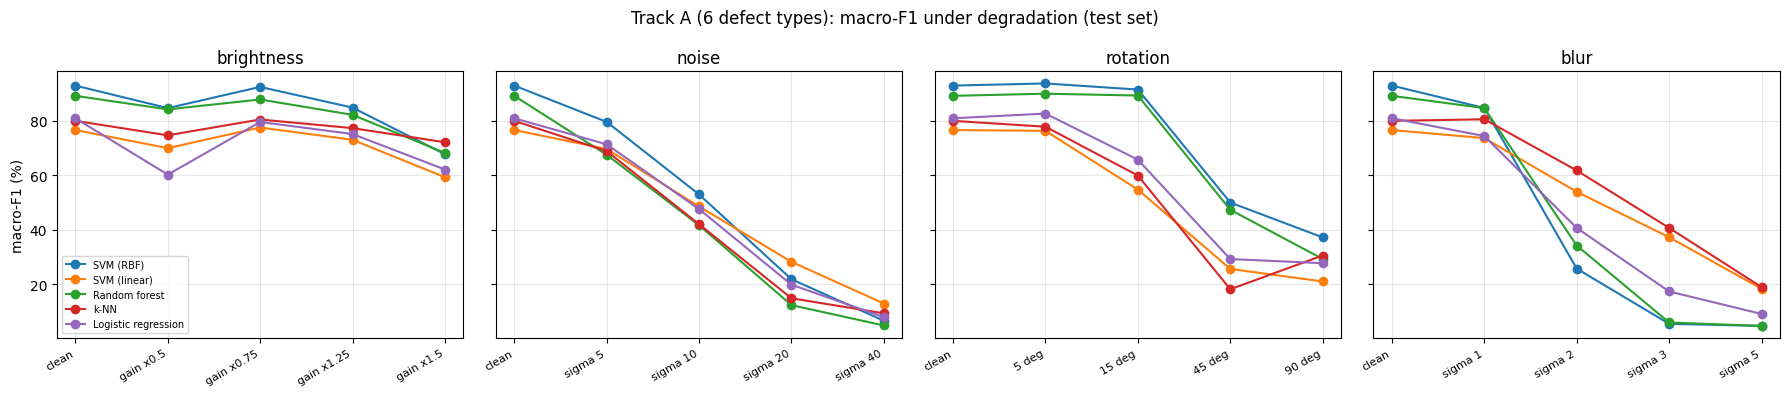

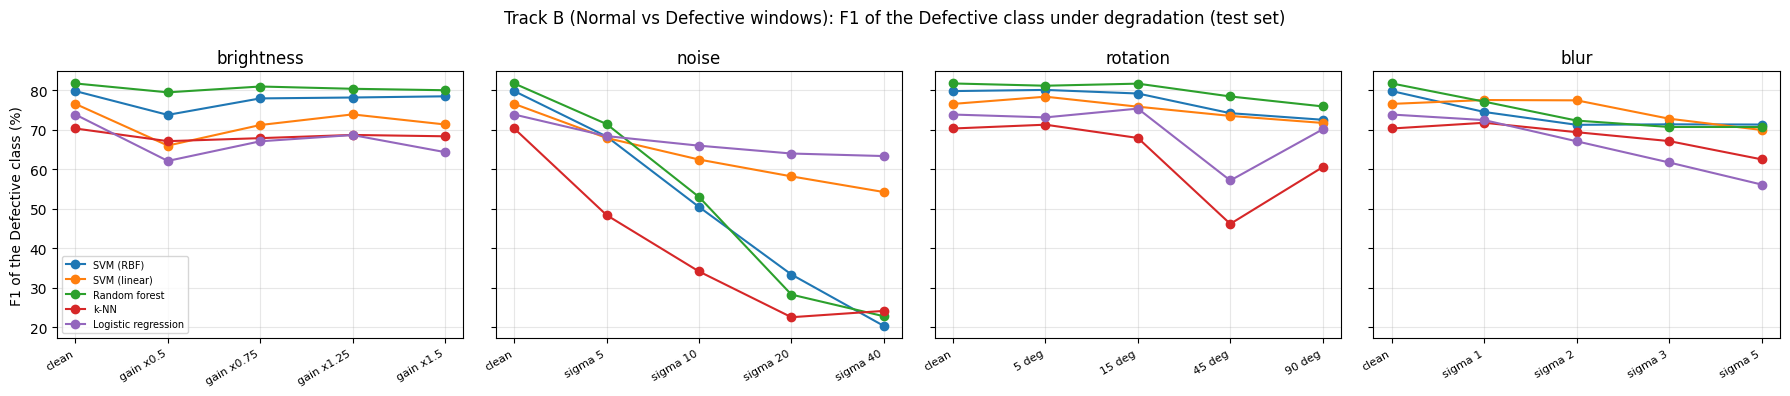

In [23]:
F1COL = {"6class": "f1", "binary": "f1_def"}
F1NAME = {"6class": "macro-F1", "binary": "F1 of the Defective class"}

def robust_table(track, clf_name):
    d = ROB.where(track=track, clf=clf_name)
    clean = d[d["cond"] == "clean"].iloc[0]
    rows = []
    for cond, level in CONDS[1:]:
        r = d[(d["cond"] == cond) & (d["level"] == LV(level))].iloc[0]
        rows.append(dict(condition=cond, level=UNIT[cond].format(LV(level)),
                         accuracy=round(100 * r["acc"], 2), d_accuracy=round(100 * (r["acc"] - clean["acc"]), 2),
                         F1=round(100 * r[F1COL[track]], 2), d_F1=round(100 * (r[F1COL[track]] - clean[F1COL[track]]), 2)))
    return clean, pd.DataFrame(rows)

for track in ("6class", "binary"):
    for n in ["SVM (RBF)", EXTRAS.get(f"second_classifier_{track}")]:
        clean, tab = robust_table(track, n)
        print(f"\n{track} | {n} | clean: accuracy {100 * clean['acc']:.2f}%, {F1NAME[track]} {100 * clean[F1COL[track]]:.2f}%   (d_ = change vs clean, in points)")
        print(tab.to_string(index=False))

def robust_figure(track, fname):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    for ax, (cond, levels) in zip(axes, CONFIG["robust_levels"].items()):
        for n in CLF_NAMES:
            d = ROB.where(track=track, clf=n)
            ys = [d[d["cond"] == "clean"].iloc[0][F1COL[track]]] + [d[(d["cond"] == cond) & (d["level"] == LV(l))].iloc[0][F1COL[track]] for l in levels]
            ax.plot(range(len(ys)), 100 * np.array(ys), marker="o", label=n)
        ax.set_xticks(range(len(levels) + 1)); ax.set_xticklabels(["clean"] + [UNIT[cond].format(LV(l)) for l in levels], rotation=30, ha="right", fontsize=8)
        ax.set_title(cond); ax.grid(alpha=0.3)
    axes[0].set_ylabel(F1NAME[track] + " (%)"); axes[0].legend(fontsize=7)
    plt.suptitle(f"{'Track A (6 defect types)' if track == '6class' else 'Track B (Normal vs Defective windows)'}: {F1NAME[track]} under degradation (test set)")
    plt.tight_layout(); save_fig(fname); plt.show()

robust_figure("6class", "task12_robustness_track_a")
robust_figure("binary", "task12_robustness_track_b")

## Task 13: Quality-control decision module

One function, `inspect_product(image)`, turns a surface image into an ACCEPT / REJECT decision in two stages:

1. **Screening (Track B).** Slide a 64x64 window over the image (5x5 = 25 windows for a 200x200 image) and ask the Normal-vs-Defective RBF SVM for P(defect) in each window. If the most suspicious window has P(defect) at or above the threshold (0.5 by default), the product is **REJECTED**; otherwise it is **ACCEPTED**. A 64x64 input is treated as a single window.
2. **Defect type (Track A).** For a rejected product, the 6-class RBF SVM looks at the whole image (resized to 128x128) and names the defect type.

Confidence is the calibrated probability of the decision: the top window's P(defect) for a rejection, and 1 minus it for an acceptance. The threshold is the knob a factory would tune: lower it to miss fewer defects, raise it to reject fewer good products (see the threshold table in Section 8.2).

In [24]:
import skimage

CLS_6 = get_or_fit("6class", "SVM (RBF)")[0]
CLS_B = get_or_fit("binary", "SVM (RBF)")[0]
HOG6, HOGB = TRACK["6class"], TRACK["binary"]

def to_gray_uint8(img):
    if isinstance(img, (str, os.PathLike)):
        return np.array(Image.open(img).convert("L"))
    if isinstance(img, Image.Image):
        return np.array(img.convert("L"))
    a = np.asarray(img)
    if a.ndim == 3:
        a = cv2.cvtColor(a.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    return a.astype(np.uint8)

def scan_windows(g, win, stride):
    H, W = g.shape
    if H < win or W < win:
        g = cv2.resize(g, (max(W, win), max(H, win)), interpolation=cv2.INTER_LINEAR)
        H, W = g.shape
    nx, ny = int(np.ceil((W - win) / stride)) + 1, int(np.ceil((H - win) / stride)) + 1
    xs = np.unique(np.round(np.linspace(0, W - win, nx)).astype(int))
    ys = np.unique(np.round(np.linspace(0, H - win, ny)).astype(int))
    pos = [(int(x), int(y)) for y in ys for x in xs]
    return g, np.stack([g[y:y + win, x:x + win] for x, y in pos]), pos

def inspect_product(img, tau=None, verbose=True):
    '''img: file path, PIL image or numpy array (gray or RGB). Returns a dict and (optionally) prints the inspection report.'''
    tau = CONFIG["reject_threshold"] if tau is None else tau
    g, wins, pos = scan_windows(to_gray_uint8(img), WIN, CONFIG["scan_stride"])
    Xw = np.stack([hog_vec(w, HOGB["cell"], HOGB["orient"]) for w in wins])
    probs = CLS_B.predict_proba(Xw)[:, list(CLS_B.classes_).index(1)]
    k = int(np.argmax(probs))
    p_max = float(probs[k])
    defective = p_max >= tau
    out = dict(prediction="DEFECTIVE" if defective else "NON-DEFECTIVE",
               confidence=p_max if defective else 1.0 - p_max,
               action="REJECT PRODUCT" if defective else "ACCEPT PRODUCT",
               p_max=p_max, worst_window=pos[k], window_probs=probs, positions=pos,
               defect_type=None, type_confidence=None)
    if defective and min(g.shape) >= 100:
        x6 = hog_vec(cv2.resize(g, (S, S), interpolation=cv2.INTER_AREA), HOG6["cell"], HOG6["orient"])[None, :]
        lab = int(CLS_6.predict(x6)[0])
        out["defect_type"] = CLASSES[lab]
        out["type_confidence"] = float(CLS_6.predict_proba(x6)[0][list(CLS_6.classes_).index(lab)])
    if verbose:
        print("PRODUCT INSPECTION RESULT")
        print(f"Prediction: {out['prediction']}")
        print(f"Confidence: {100 * out['confidence']:.1f}%")
        print(f"Action: {out['action']}")
        if out["defect_type"]:
            print(f"  details: defect type = {out['defect_type']} ({100 * out['type_confidence']:.1f}% confidence), "
                  f"most suspicious window at x={out['worst_window'][0]}, y={out['worst_window'][1]}")
    return out

# ---- demo: three defective test images (different types) and three Normal test windows ----
print("=" * 70)
shown_types = set()
for i in test_idx:
    c = meta.at[i, "label"]
    if c in shown_types or len(shown_types) >= 3:
        continue
    shown_types.add(c)
    print(f"[true defect type: {c}]")
    inspect_product(GRAY_NATIVE[i])
    print("-" * 70)
norm_test = [j for j in w_test if yw[j] == 0][:3]
for j in norm_test:
    print("[a Normal 64x64 window from the test set]")
    inspect_product(WIN_X[j])
    print("-" * 70)

# ---- save what the later webcam / interface step needs ----
INSPECTION_CONFIG = dict(
    run_id=RUN_SIG, classes=CLASSES, binary_classes=["Normal", "Defective"], img_size=S, win_size=WIN,
    scan_stride=CONFIG["scan_stride"], reject_threshold=CONFIG["reject_threshold"],
    hog_track_a=dict(cell=HOG6["cell"], orient=HOG6["orient"], block=HB, block_norm=HNORM),
    hog_track_b=dict(cell=HOGB["cell"], orient=HOGB["orient"], block=HB, block_norm=HNORM),
    model_track_a=os.path.basename(model_path("6class", "SVM (RBF)")), model_track_b=os.path.basename(model_path("binary", "SVM (RBF)")),
    preprocessing="grayscale; Track A: cv2.resize to img_size x img_size with INTER_AREA; Track B: native-resolution 64x64 windows",
    versions=dict(sklearn=sklearn.__version__, skimage=skimage.__version__, numpy=np.__version__, opencv=cv2.__version__))
_atomic_write(os.path.join(MODEL_DIR, "inspection_config.json"), json.dumps(INSPECTION_CONFIG, indent=1, default=_json_default))
print("Saved models and inspection_config.json to", MODEL_DIR)

[true defect type: crazing]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 93.8%
Action: REJECT PRODUCT
  details: defect type = crazing (89.7% confidence), most suspicious window at x=102, y=34
----------------------------------------------------------------------
[true defect type: inclusion]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 92.0%
Action: REJECT PRODUCT
  details: defect type = inclusion (95.0% confidence), most suspicious window at x=136, y=102
----------------------------------------------------------------------
[true defect type: patches]
PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 99.4%
Action: REJECT PRODUCT
  details: defect type = patches (98.4% confidence), most suspicious window at x=34, y=34
----------------------------------------------------------------------
[a Normal 64x64 window from the test set]
PRODUCT INSPECTION RESULT
Prediction: NON-DEFECTIVE
Confidence: 56.9%
Action: ACCEPT PRODUCT
------------------------

In [25]:
# ---- end-to-end check on the held-out test images (every one of them is truly defective) ----
t0 = time.time()
recs = []
for i in test_idx:
    r = inspect_product(GRAY_NATIVE[i], verbose=False)
    recs.append(dict(idx=int(i), true=meta.at[i, "label"], decision=r["prediction"], p_max=r["p_max"],
                     type_pred=r["defect_type"], type_conf=r["type_confidence"]))
latency_ms = 1000 * (time.time() - t0) / len(test_idx)
E2E = pd.DataFrame(recs)

detected = E2E["decision"] == "DEFECTIVE"
type_ok = (E2E["type_pred"] == E2E["true"])[detected]
p_norm = np.array(EXTRAS.get("pdef_binary_test"))[yw_test == 0]
e2e = dict(images=len(E2E), detection_rate=float(detected.mean()), missed=int((~detected).sum()),
           type_accuracy_of_rejected=float(type_ok.mean()) if detected.any() else float("nan"),
           normal_windows=int(len(p_norm)), normal_accept_rate=float((p_norm < CONFIG["reject_threshold"]).mean()),
           latency_ms_per_image=latency_ms)
EXTRAS.set("e2e_summary", e2e)
print(f"Defective test images:    {e2e['images']}")
print(f"  REJECTED (detected):    {int(detected.sum())}  ({100 * e2e['detection_rate']:.2f}%)   missed (ACCEPTED by mistake): {e2e['missed']}")
print(f"  defect type correct among the rejected: {100 * e2e['type_accuracy_of_rejected']:.2f}%")
print(f"Normal test windows:      {e2e['normal_windows']}  ->  ACCEPTED {100 * e2e['normal_accept_rate']:.2f}% at threshold {CONFIG['reject_threshold']}")
print(f"Decision time: {latency_ms:.1f} ms per 200x200 image (25 windows + defect type) on this runtime")
print("\nDetection rate by true defect type (test images):")
print((100 * detected.groupby(E2E["true"]).mean()).round(1).reindex(CLASSES).to_string())

rows = []
for tau in (0.1, 0.3, 0.5, 0.7, 0.9):
    rows.append(dict(threshold=tau, image_detection_rate=round(100 * float((E2E["p_max"] >= tau).mean()), 2),
                     normal_window_false_reject=round(100 * float((p_norm >= tau).mean()), 2)))
print("\nThreshold effect (images: share of defective test images rejected; windows: share of Normal test windows rejected):")
print(pd.DataFrame(rows).to_string(index=False))

Defective test images:    270
  REJECTED (detected):    270  (100.00%)   missed (ACCEPTED by mistake): 0
  defect type correct among the rejected: 92.96%
Normal test windows:      383  ->  ACCEPTED 75.46% at threshold 0.5
Decision time: 50.9 ms per 200x200 image (25 windows + defect type) on this runtime

Detection rate by true defect type (test images):
true
crazing            100.0
inclusion          100.0
patches            100.0
pitted_surface     100.0
rolled-in_scale    100.0
scratches          100.0

Threshold effect (images: share of defective test images rejected; windows: share of Normal test windows rejected):
 threshold  image_detection_rate  normal_window_false_reject
       0.1                100.00                       75.72
       0.3                100.00                       47.52
       0.5                100.00                       24.54
       0.7                 97.78                       10.70
       0.9                 78.15                        1.31


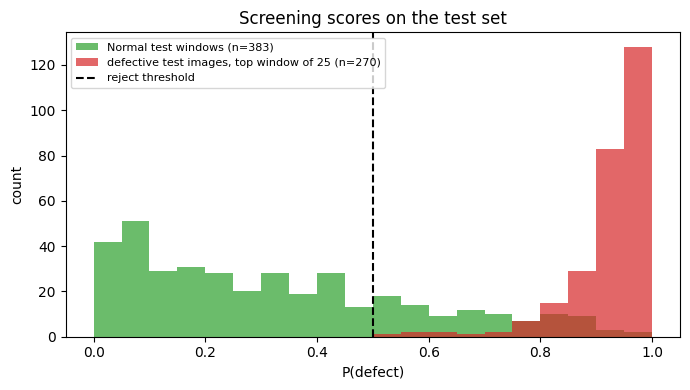

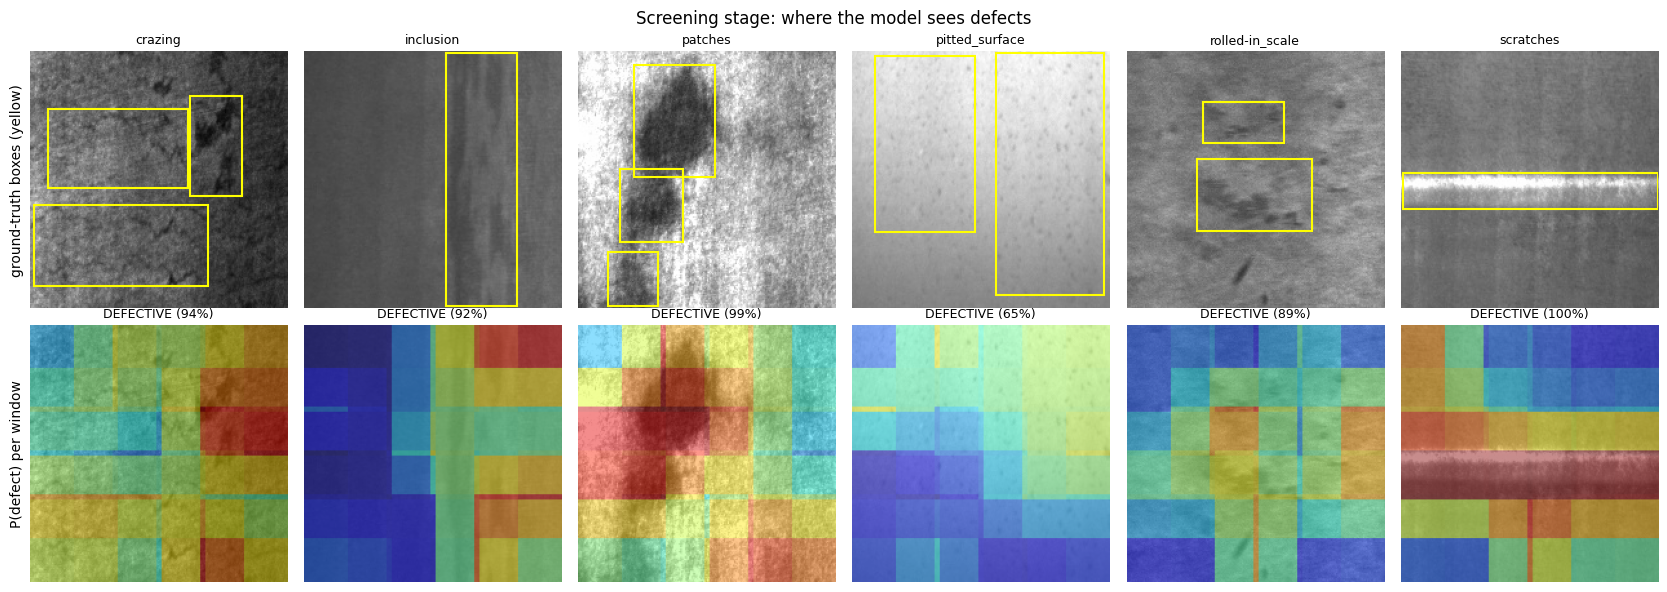

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(p_norm, bins=np.linspace(0, 1, 21), alpha=0.7, color="tab:green", label=f"Normal test windows (n={len(p_norm)})")
ax.hist(E2E["p_max"], bins=np.linspace(0, 1, 21), alpha=0.7, color="tab:red", label=f"defective test images, top window of 25 (n={len(E2E)})")
ax.axvline(CONFIG["reject_threshold"], color="k", linestyle="--", label="reject threshold")
ax.set_xlabel("P(defect)"); ax.set_ylabel("count"); ax.set_title("Screening scores on the test set"); ax.legend(fontsize=8)
plt.tight_layout(); save_fig("task13_screening_score_histogram"); plt.show()

# Where does the screening stage look? Window probabilities painted back onto six defective test images
def heat_from(r, shape):
    acc, cnt = np.zeros(shape), np.zeros(shape)
    for p, (x0, y0) in zip(r["window_probs"], r["positions"]):
        acc[y0:y0 + WIN, x0:x0 + WIN] += p
        cnt[y0:y0 + WIN, x0:x0 + WIN] += 1
    return acc / np.maximum(cnt, 1)

first_of = {}
for i in test_idx:
    first_of.setdefault(meta.at[i, "label"], int(i))
cls_show = [c for c in CLASSES if c in first_of]
fig, axes = plt.subplots(2, len(cls_show), figsize=(2.8 * len(cls_show), 6))
axes = np.array(axes).reshape(2, -1)
for j, c in enumerate(cls_show):
    i = first_of[c]
    r = inspect_product(GRAY_NATIVE[i], verbose=False)
    axes[0, j].imshow(GRAY_NATIVE[i], cmap="gray", vmin=0, vmax=255)
    for x1, y1, x2, y2 in meta.at[i, "boxes"]:
        axes[0, j].add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5))
    axes[0, j].set_title(c, fontsize=9)
    axes[1, j].imshow(GRAY_NATIVE[i], cmap="gray", vmin=0, vmax=255)
    hm = axes[1, j].imshow(heat_from(r, GRAY_NATIVE[i].shape), cmap="jet", alpha=0.45, vmin=0, vmax=1)
    axes[1, j].set_title(f"{r['prediction']} ({100 * r['confidence']:.0f}%)", fontsize=9)
    _clean_axis(axes[0, j]); _clean_axis(axes[1, j])
axes[0, 0].set_ylabel("ground-truth boxes (yellow)"); axes[1, 0].set_ylabel("P(defect) per window")
plt.suptitle("Screening stage: where the model sees defects")
plt.tight_layout(h_pad=1.6); save_fig("task13_window_scan_heatmaps"); plt.show()

## SummarY

In [27]:
def pct(x): return round(100 * float(x), 2)

summary = dict(run_id=RUN_SIG, images=len(meta), split=dict(train=int((meta["split"] == "train").sum()), val=int((meta["split"] == "val").sum()), test=len(test_idx)),
               windows=dict(total=len(win_meta), normal=int((yw == 0).sum()), defective=int((yw == 1).sum())),
               best_hog=dict(track_a=EXTRAS.get("best_hog_6class"), track_b=EXTRAS.get("best_hog_binary")),
               test_svm_rbf=dict(track_a={k: pct(CMP.where(track="6class", clf="SVM (RBF)").iloc[0][k]) for k in ("acc", "prec", "rec", "f1")},
                                 track_b={k: pct(CMP.where(track="binary", clf="SVM (RBF)").iloc[0][k]) for k in ("acc", "prec_def", "rec_def", "f1_def", "auc")}),
               end_to_end=EXTRAS.get("e2e_summary"))
rob = {}
for track in ("6class", "binary"):
    _, tab = robust_table(track, "SVM (RBF)")
    rob[track] = {cond: dict(worst_level=tab[tab["condition"] == cond].sort_values("d_F1").iloc[0]["level"],
                             worst_d_F1=float(tab[tab["condition"] == cond]["d_F1"].min()),
                             worst_d_accuracy=float(tab[tab["condition"] == cond]["d_accuracy"].min())) for cond in CONFIG["robust_levels"]}
summary["robustness_svm_rbf_worst_case"] = rob
_atomic_write(os.path.join(CKPT_DIR, "results_summary.json"), json.dumps(summary, indent=1, default=_json_default))
print(json.dumps(summary, indent=1, default=_json_default))

print("\nFiles saved in", CKPT_DIR)
for root, _, files in sorted(os.walk(CKPT_DIR)):
    for f in sorted(files):
        p = os.path.join(root, f)
        print(f"  {os.path.relpath(p, CKPT_DIR):<52} {os.path.getsize(p) / 1e6:8.2f} MB")

{
 "run_id": "37c9b548",
 "images": 1800,
 "split": {
  "train": 1260,
  "val": 270,
  "test": 270
 },
 "windows": {
  "total": 5741,
  "normal": 2624,
  "defective": 3117
 },
 "best_hog": {
  "track_a": {
   "cell": 16,
   "orient": 12,
   "dim": 2352,
   "f1_mean": 0.9223319691236211,
   "top_cell": 16,
   "top_orient": 12,
   "top_f1": 0.9223319691236211
  },
  "track_b": {
   "cell": 16,
   "orient": 6,
   "dim": 216,
   "f1_mean": 0.774100832983019,
   "top_cell": 16,
   "top_orient": 12,
   "top_f1": 0.7784122583830025
  }
 },
 "test_svm_rbf": {
  "track_a": {
   "acc": 92.96,
   "prec": 92.99,
   "rec": 92.96,
   "f1": 92.89
  },
  "track_b": {
   "acc": 78.11,
   "prec_def": 81.72,
   "rec_def": 77.94,
   "f1_def": 79.78,
   "auc": 87.13
  }
 },
 "end_to_end": {
  "images": 270,
  "detection_rate": 1.0,
  "missed": 0,
  "type_accuracy_of_rejected": 0.9296296296296296,
  "normal_windows": 383,
  "normal_accept_rate": 0.7545691906005222,
  "latency_ms_per_image": 50.8584004861337